# Particle loss, magic and encoded probes — the quantum Fisher information of the survivors

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

Every atom interferometer loses atoms. Ions leave the trap, photons miss the detector, a pixel goes dark. The phase
$\theta$ was imprinted on all $N$ particles, but only $N-k$ of them are measured, and the question a laboratory must
answer before building anything is: **how much of the quantum advantage survives?**

The answer is not a detail. Notebook 29 found that a GHZ state — the probe that saturates the Heisenberg limit
$F_Q=N^2$ — is destroyed by the loss of one single particle. If that were the whole story, quantum-enhanced metrology
would be a curiosity rather than a technology. It is not the whole story: other probes degrade gracefully, and a probe
can even be *encoded* so that the phase it carries is immune to the loss of several particles. This notebook measures
all of it.

Three questions organise the work.

1. **The exact loss law of each probe.** Losing $k$ of $N$ qubits turns a pure state into a mixed state of the
   survivors, so we need the symmetric-logarithmic-derivative (SLD) quantum Fisher information of a reduced state.
   We derive a short-cut that makes the computation cheap, validate it three ways, and then derive closed-form loss
   laws for product, GHZ, W and Dicke probes and check them against the numbers.
2. **Structural predictors of robustness.** We compare the loss curves with the entanglement
   entropy, with the entanglement spectrum, and with the **magic** (stabilizer Rényi entropy $M_2$) of the same states.
   None of the three predicts the loss curve of the probe zoo; Section 6 shows what does.
3. **A defence against loss.** Imprint the phase on a GHZ state first and then *encode* the result with a
   Clifford circuit. The encoded probe is a two-dimensional quantum error-correcting code, and the loss of $k$
   particles is an **erasure**. We measure a sharp all-or-nothing threshold, derive it from the logical operators of
   the code, check which erasure patterns it survives, and then measure the price: the same encoded state is a poor
   probe for a local collective generator.

**Road map.**

* **Sections 3–4** — loss as a partial trace; the reduced-state QFI, a commutator lemma that makes it a *local*
  problem for local generators, Schmidt compression, and three independent implementations that must agree.
* **Sections 5–6** — the exact loss laws (product, GHZ, W, Dicke, derived) and the measured loss curves of the whole
  probe zoo, including the one-axis-twisting family of notebooks 33–35 and Haar-random states.
* **Section 7** — magic: the stabilizer Rényi entropy $M_2$ of every probe, and whether it predicts robustness.
* **Sections 8–11** — encoded probes: the Clifford erasure code, its threshold and the three-case rule that explains
  it (Section 9.1), every erasure pattern rather than only the last $k$ qubits (Section 9.2), the tunable-magic
  encoder, and the protection-versus-sensitivity trade-off.
* **Section 12** — the entanglement spectrum of the encoders and the Marchenko–Pastur law.

### What you will learn

*Physics*

* why losing one particle of a GHZ state sets $F_Q$ to exactly zero, and exactly what is left if the generator
  direction is re-optimised afterwards;
* the closed-form loss law of Dicke states (and of the W state as its $M=1$ member), derived from the hypergeometric
  Schmidt weights of a symmetric state;
* that "how entangled" and "how much magic" are both poor predictors of loss robustness; what decides is whether the
  generator restricted to the survivors can still move their state;
* how a quantum error-correcting code turns graceful degradation into a sharp erasure threshold, why the threshold
  depends on *which* qubits are lost, and why the same encoded state is a poor probe for a local generator.

*Numerical methods*

* the SLD quantum Fisher information of a reduced state from the state and a single *tangent vector*, with no finite
  differences and no $\rho_\theta$ ever built;
* rank-revealing QR compression: keeping $N-1$ qubits costs the same as keeping one;
* the $O(N4^N)$ Walsh–Hadamard algorithm for the stabilizer Rényi entropy, reused from notebook 27;
* Marchenko–Pastur as a quantitative reference for an entanglement spectrum.

*Implementation practice*

* `jax.jit` with static qubit indices; `jax.vmap` over realisations; explicit PRNG keys;
* validating one quantity against three independent code paths before a single plot is drawn;
* choosing a figure of merit that cannot be gamed (relative retention flatters weak probes; a *loss budget* does not).

### Prerequisites
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb): reduced
  density matrices, Schmidt decomposition, entanglement entropy;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb);
* [29 — quantum Fisher information](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb): the QFI,
  the standard quantum and Heisenberg limits, the $3\times3$ QFI matrix, the subsystem QFI;
* [30 — QFI from the SLD](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb): the
  symmetric logarithmic derivative and the mixed-state QFI, derived;
* [27 — stabilizer Rényi entropy](../ch09_entanglement_and_complexity/27_stabilizer_renyi_entropy.ipynb): Pauli group,
  stabilizer states, Clifford circuits, magic;
* helpful: [33 — spin squeezing](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb),
  [34 — one-axis twisting to GHZ](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb) and
  [35 — one-axis twisting plus Haar scrambling](../ch10_quantum_metrology_protocols/35_oat_plus_haar_scrambling.ipynb).

**Conventions.** Qubit $q$ = tensor axis $q$; $\vert 0\rangle$ is the $+1$ eigenstate of $Z$. Collective spins are
$J_a=\tfrac12\sum_q\sigma^a_q$, so the standard quantum limit is $F_Q=N$ and the Heisenberg limit is $F_Q=N^2$. The
parameter is imprinted by $U(\theta)=e^{-i\theta G}$. Throughout, $k$ is the number of **lost** qubits and
$K=N-k$ the number of **kept** ones; the lost qubits are the last $k$ unless stated otherwise.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we take the state constructors, `apply_gate`, `rdm`, `apply_collective`, `spin_moments`, `qfi_pure`,
`qfi_mixed`, `collective_dense`, `oat_evolve`, the Clifford group and the Walsh–Hadamard transform used by the magic
calculation. Everything else is built below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (copied from quantum_engine.py, the SmoQ.jax engine)
# Every function below is explained, with its mathematics and an independent check, in
# notebook 08b (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def spin_squeezing(psi):
    """Wineland spin-squeezing parameter
        xi^2_R = N * min_{n_perp} Var(J_{n_perp}) / |<J>|^2 .
    xi^2 < 1: phase sensitivity beyond the standard quantum limit (and the state is entangled).
    Implementation: project the 3x3 covariance onto the plane perpendicular to the mean spin and take
    the smaller eigenvalue of the resulting 2x2 matrix."""
    N = psi.ndim
    mean, cov = spin_moments(psi)
    L = jnp.linalg.norm(mean)
    n = mean / L
    a = jnp.where(jnp.abs(n[2]) < 0.9, jnp.array([0.0, 0.0, 1.0]), jnp.array([1.0, 0.0, 0.0]))
    e1 = jnp.cross(n, a)
    e1 = e1 / jnp.linalg.norm(e1)
    e2 = jnp.cross(n, e1)
    B = jnp.stack([e1, e2])
    vmin = jnp.linalg.eigvalsh(B @ cov @ B.T)[0]
    return N * vmin / L ** 2

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]

def brickwall(key, psi, depth, periodic=False):
    """Random brick-wall circuit: layers of Haar-random 2-qubit gates on even bonds, then odd bonds, ...
    Depth ~ N turns a product state into a (nearly) Haar-random state: volume-law entanglement (Page)."""
    N = psi.ndim
    for layer in range(depth):
        bonds = [(i, i + 1) for i in range(layer % 2, N - 1, 2)]
        if periodic and N % 2 == 0 and layer % 2 == 1:
            bonds.append((N - 1, 0))
        key, *ks = jax.random.split(key, len(bonds) + 1)
        for k, b in zip(ks, bonds):
            psi = apply_gate(psi, haar_unitary(k, 4), b)
    return psi


# ----------------------------------------------------------------------------
# 14. Stabilizer Renyi entropy ("magic") via the fast Walsh-Hadamard transform
# ----------------------------------------------------------------------------
def _wht_all_axes(f):
    """Unnormalised Walsh-Hadamard transform over all N binary axes:
        F[b] = sum_s (-1)^{b.s} f[s]
    In tensor language it is simply [[1,1],[1,-1]] applied to EVERY axis: N einsums, O(N 2^N)."""
    Hun = jnp.array([[1, 1], [1, -1]], dtype=f.dtype)
    for q in range(f.ndim):
        f = apply_gate(f, Hun, [q])
    return f


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#8c8c8c", "#00868b"]
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def timed(f, *args, budget=0.3, min_reps=3, max_reps=200):
    """Return (result, compile_time, best_run_time); JAX is asynchronous, so every value is forced with
    `block_until_ready`, and we report the MINIMUM over repetitions (on a shared machine the mean measures
    the operating system, the minimum measures the code)."""
    t0 = time.time()
    out = jax.block_until_ready(f(*args))
    t_compile = time.time() - t0
    best, n, t_start = np.inf, 0, time.time()
    while n < min_reps or (time.time() - t_start < budget and n < max_reps):
        t0 = time.time()
        out = jax.block_until_ready(f(*args))
        best = min(best, time.time() - t0)
        n += 1
    return out, t_compile, best

## 3. Losing particles: the state of the survivors

### 3.1 The set-up

The probe $\vert\psi\rangle$ of $N$ qubits is prepared, the phase is imprinted on **all** of them,

$$\vert\psi_\theta\rangle=e^{-i\theta G}\vert\psi\rangle,$$

and then $k$ qubits are lost. "Lost" means: they leave the experiment and nobody ever measures them. Quantum
mechanics says that the state of what remains is the **partial trace** over the lost qubits,

$$\rho_A(\theta)=\mathrm{Tr}_B\left[\,\vert\psi_\theta\rangle\langle\psi_\theta\vert\,\right],
  \qquad A=\text{kept},\quad B=\text{lost}. \tag{1}$$

This is a *mixed* state even though the probe was pure, so its quantum Fisher information is the general SLD
expression derived in notebook 30,

$$F_Q=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}
  \frac{\left\vert\langle m\vert\partial_\theta\rho_A\vert n\rangle\right\vert^2}{\lambda_m+\lambda_n},
  \qquad \rho_A=\sum_m\lambda_m\vert m\rangle\langle m\vert. \tag{2}$$

Everything in this notebook is an evaluation of Eq. (2) for a different $(\rho_A,\partial_\theta\rho_A)$ pair.

### 3.2 A lemma that makes local generators easy

Most generators in metrology are **sums of single-qubit terms**, $G=\sum_q g_q$. Split the sum into the kept and the
lost qubits, $G=G_A\otimes\mathbb 1_B+\mathbb 1_A\otimes G_B$. Then

$$\partial_\theta\rho_A
  =\mathrm{Tr}_B\left(-i\left[G,\rho\right]\right)
  =-i\,\mathrm{Tr}_B\left(\left[G_A\otimes\mathbb 1,\rho\right]\right)
   -i\,\mathrm{Tr}_B\left(\left[\mathbb 1\otimes G_B,\rho\right]\right).$$

The first term is $-i\left[G_A,\mathrm{Tr}_B\rho\right]$, because an operator acting only on $A$ can be pulled out of
a trace over $B$. The second term **vanishes**: $\mathrm{Tr}_B\left((\mathbb 1\otimes G_B)\rho\right)
=\mathrm{Tr}_B\left(\rho(\mathbb 1\otimes G_B)\right)$ by cyclicity of the trace *inside* $B$. Hence

$$\boxed{\;\partial_\theta\rho_A=-i\left[G_A,\rho_A\right]\;} \tag{3}$$

— the survivors evolve under the *restriction of the generator to the survivors*, and nothing else. Two consequences
we shall use constantly:

* the QFI of the survivors is simply $F_Q[\rho_A,G_A]$, the ordinary mixed-state QFI of a $2^K$-dimensional state;
* if the generator has **no support** on the kept qubits, $G_A=0$ and the survivors carry no information at all.

### 3.3 Generators that are not local sums

Equation (3) fails as soon as $G$ is not a sum of local terms — and Section 8 needs exactly that case, because
encoding a probe with a unitary $V$ turns the generator into $V G V^\dagger$, a complicated many-body operator. The
general route uses a **tangent vector**. Write the state and its derivative as matrices:

$$\Psi\in\mathbb C^{2^K\times2^{N-K}}:\ \Psi[(a),(b)]=\psi[a,b],\qquad
  \Phi\in\mathbb C^{2^K\times2^{N-K}}:\ \Phi[(a),(b)]=\left(G\psi\right)[a,b],$$

i.e. group the kept axes into a row index and the lost axes into a column index. Then $\rho_A=\Psi\Psi^\dagger$ and,
with $T=\Phi\Psi^\dagger$,

$$\partial_\theta\rho_A=\mathrm{Tr}_B\left(-i\left[G,\vert\psi\rangle\langle\psi\vert\right]\right)
  =-i\left(T-T^\dagger\right). \tag{4}$$

(The first equality is $\partial_\theta\rho=-i[G,\rho]$ at $\theta=0$; the second is the observation that
$\mathrm{Tr}_B\left(\vert\phi\rangle\langle\psi\vert\right)=\Phi\Psi^\dagger$ in the matrix view.)

**The value of $\theta$ matters for non-local generators.** For a local generator Eq. (3) gives
$\rho_A(\theta)=e^{-i\theta G_A}\rho_Ae^{i\theta G_A}$, a unitary orbit, and the QFI does not depend on $\theta$
(notebook 30, Section 5.5a), so $\theta=0$ is no restriction. For a generator that does not split into a kept and a
lost part, $\rho_A(\theta)$ is *not* a unitary orbit and its QFI may depend on $\theta$. Equation (4) holds at any
$\theta$ if $\vert\psi\rangle$ is replaced by $\vert\psi_\theta\rangle$ and $\vert\phi\rangle$ by
$G\vert\psi_\theta\rangle$; Sections 8–11 evaluate it at $\theta=0$ and Section 9.2 measures what changes at
$\theta\neq0$.

Only $\vert\phi\rangle=G\vert\psi\rangle$ is needed; whatever $G$ is, if we can *apply* it we can compute the QFI of
every subsystem. This is the pattern used for the rest of the notebook: **carry the tangent vector alongside the
state**.

### 3.4 Schmidt compression

Equation (2) needs an eigendecomposition of $\rho_A$, costing $O(8^K)$. Losing *one* qubit would then be the most
expensive case, even though it barely mixes the state. But $\rho_A=\Psi\Psi^\dagger$ has rank at most $2^{N-K}$, and
both $\rho_A$ and $\partial_\theta\rho_A$ live inside the column span of $\left[\,\Psi\ \ \Phi\,\right]$, a subspace of
dimension at most $2\cdot2^{N-K}$. A thin QR decomposition $\left[\,\Psi\ \ \Phi\,\right]=QR$ gives an isometry onto
it; projecting with $Q^\dagger$ leaves the non-zero spectrum and every matrix element of Eq. (2) unchanged and drops
the cost to $O\!\left(8^{\min(K,N-K)}\right)$. This is the routine derived in notebook 29, Section 14; we copy it and
generalise it to an arbitrary tangent vector.

In [4]:
# ==============================================================================
# STEP 1: the reduced-state QFI -- three routines
#   (derived in notebook 29 Sec. 14 and notebook 30 Sec. 6; generalised here to
#    an arbitrary tangent vector |phi> = G|psi>)
# ==============================================================================
def qfi_from_derivative(rho, drho, tol=1e-12):
    """SLD quantum Fisher information of a state and its derivative -- Eq. (2).

    MATH   F_Q = 2 sum_{m,n} |<m|drho|n>|^2 / (lam_m + lam_n)  over lam_m + lam_n > tol,
           with rho = sum_m lam_m |m><m|.    (Derived in notebook 30, Sec. 5.)
    COST   one Hermitian eigendecomposition, O(dim^3).
    """
    lam, v = jnp.linalg.eigh(rho)
    D = v.conj().T @ drho @ v
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    return 2 * jnp.sum(jnp.where(ok, jnp.abs(D) ** 2 / jnp.where(ok, den, 1.0), 0.0))


def block_qfi(psi, phi, keep, compress=True, tol=1e-12):
    """QFI of the reduced state of the qubits `keep`, for ANY generator, from the tangent vector.

    MATH   Psi = psi with the kept axes grouped first, reshaped to (2^K, 2^{N-K});  Phi = likewise for
           |phi> = G|psi>.   rho_A = Psi Psi^dag,   d rho_A/d theta = -i (T - T^dag),  T = Phi Psi^dag.  [Eq. (4)]
    IMPL   `keep` may be ANY set of qubits (a transpose puts them first).  When 2^K > 2^{N-K} a thin QR of
           [Psi | Phi] projects onto the active subspace: same spectrum, same matrix elements, smaller matrices.
    COST   O(8^min(K, N-K)) for the eigendecomposition;  O(2^N) memory.
    JAX    `keep` is a tuple of static Python ints (it fixes the transpose and the shapes); psi, phi are traced.
    """
    keep = tuple(int(q) for q in keep)
    rest = tuple(q for q in range(psi.ndim) if q not in keep)
    dA = 2 ** len(keep)
    Psi = jnp.transpose(psi, keep + rest).reshape(dA, -1)
    Phi = jnp.transpose(phi, keep + rest).reshape(dA, -1)
    if compress and Psi.shape[0] > Psi.shape[1]:
        Q, _ = jnp.linalg.qr(jnp.concatenate([Psi, Phi], axis=1))     # thin QR -> active subspace
        Psi, Phi = Q.conj().T @ Psi, Q.conj().T @ Phi
    T_ = Phi @ Psi.conj().T
    return qfi_from_derivative(Psi @ Psi.conj().T, -1j * (T_ - T_.conj().T), tol)


def pauli_direction(n):
    """Single-qubit matrix n.sigma = n_x X + n_y Y + n_z Z for a direction n (notebook 29, Sec. 8)."""
    n = jnp.asarray(n, dtype=CDTYPE)
    return n[0] * X + n[1] * Y + n[2] * Z


def collective_tangent(psi, n):
    """|phi> = (n.J)|psi> with J_a = (1/2) sum_q sigma^a_q -- matrix-free, N einsums, O(N 2^N)."""
    return 0.5 * apply_collective(psi, pauli_direction(n))


def qfi_matrix(psi):
    """3x3 collective QFI matrix, Fcal_ab = 4 C_ab, with F_Q(n) = n^T Fcal n (notebook 29, Sec. 11)."""
    _, cov = spin_moments(psi)
    return 4.0 * cov


def optimal_direction(psi):
    """Best collective generator direction and the QFI it gives: (F_max, n_opt) = largest eigenpair of Fcal."""
    w, v = jnp.linalg.eigh(qfi_matrix(psi))
    return w[-1], v[:, -1]


def clean_direction(n):
    """Fix the irrelevant global sign of an eigenvector and round numerical zeros away, for printing."""
    n = np.array(n, dtype=float)
    n = n * np.sign(n[int(np.argmax(np.abs(n)))])
    return np.where(np.abs(n) < 1e-9, 0.0, n)

### 3.5 Checkpoint: four routes to the same number

Before a single physical statement we check `block_qfi` against everything else we have:

1. **no loss** ($K=N$) must reproduce the pure-state value $4\,\mathrm{Var}(G)$;
2. the **compressed** and **uncompressed** branches must agree bit for bit in exact arithmetic;
3. for a collective generator, Eq. (3) says the answer must equal the engine's `qfi_mixed` applied to the dense
   reduced density matrix with the *restricted* generator $G_A$ — a completely different code path;
4. a **brute-force** route that builds $\rho_A(\theta)$ from the phase-imprinted state and differentiates it with
   `jax.jacfwd` — an independent test of Eq. (4). (This checkpoint uses a collective generator; Section 8 repeats the
   brute-force test for the non-local generators of encoded probes.)

In [5]:
# ==============================================================================
# CHECKPOINT 1: block_qfi against 4 Var(G), against qfi_mixed(rho_A, G_A), and against jax.jacfwd
# ==============================================================================
N_CHK = 7
chk_states = {"GHZ": ghz_state(N_CHK), "W": w_state(N_CHK),
              "Dicke 3": dicke_state(N_CHK, 3), "Haar": haar_state(jax.random.PRNGKey(2), N_CHK)}
n_chk = np.array([1.0, 2.0, -2.0]) / 3.0                       # a tilted direction, nothing special about it

print(f"N = {N_CHK}, generator G = n.J with n = {n_chk}\n")
print(f"{'state':>8s} {'K':>3s} | {'compressed':>13s} {'uncompressed':>13s} {'qfi_mixed(G_A)':>15s} "
      f"{'jacfwd':>13s} {'max err':>9s}")
err_all = 0.0
for name, psi in chk_states.items():
    phi = collective_tangent(psi, n_chk)
    for K in (2, 4, 6, 7):
        a = float(block_qfi(psi, phi, range(K), compress=True))
        b = float(block_qfi(psi, phi, range(K), compress=False))
        c = float(qfi_mixed(rdm(psi, range(K)), collective_dense(pauli_direction(n_chk), K)))

        def rho_A_of_theta(th, K=K, psi=psi):                   # brute force: encode, trace, differentiate
            U = jnp.cos(th / 2) * I2 - 1j * jnp.sin(th / 2) * pauli_direction(n_chk)
            p = psi
            for q in range(N_CHK):
                p = apply_gate(p, U, [q])
            return rdm(p, range(K))

        d = float(qfi_from_derivative(rho_A_of_theta(0.0), jax.jacfwd(rho_A_of_theta)(0.0)))
        e = max(abs(a - b), abs(a - c), abs(a - d))
        err_all = max(err_all, e)
        print(f"{name:>8s} {K:3d} | {a:13.8f} {b:13.8f} {c:15.8f} {d:13.8f} {e:9.1e}")
    # K = N must be 4 Var(G)
    f_pure = float(qfi_pure(psi, pauli_direction(n_chk)))
    err_all = max(err_all, abs(float(block_qfi(psi, phi, range(N_CHK))) - f_pure))

print(f"\nworst discrepancy over all four routes and all states: {err_all:.2e}")
assert err_all < 1e4 * TOL

N = 7, generator G = n.J with n = [ 0.33333333  0.66666667 -0.66666667]

   state   K |    compressed  uncompressed  qfi_mixed(G_A)        jacfwd   max err


     GHZ   2 |    1.11111111    1.11111111      1.11111111    1.11111111   0.0e+00


     GHZ   4 |    2.22222222    2.22222222      2.22222222    2.22222222   4.4e-16


     GHZ   6 |    3.33333333    3.33333333      3.33333333    3.33333333   4.4e-16


     GHZ   7 |   25.66666667   25.66666667     25.66666667   25.66666667   1.1e-14


       W   2 |    0.52154195    0.52154195      0.52154195    0.52154195   3.3e-16
       W   4 |    1.95011338    1.95011338      1.95011338    1.95011338   8.9e-16
       W   6 |    6.46258503    6.46258503      6.46258503    6.46258503   5.3e-15
       W   7 |   10.55555556   10.55555556     10.55555556   10.55555556   2.5e-14
 Dicke 3   2 |    0.39153439    0.39153439      0.39153439    0.39153439   1.7e-16
 Dicke 3   4 |    1.80770341    1.80770341      1.80770341    1.80770341   8.9e-16


 Dicke 3   6 |    6.32653061    6.32653061      6.32653061    6.32653061   2.7e-15
 Dicke 3   7 |   17.22222222   17.22222222     17.22222222   17.22222222   5.3e-14
    Haar   2 |    0.07279199    0.07279199      0.07279199    0.07279199   0.0e+00
    Haar   4 |    2.62936969    2.62936969      2.62936969    2.62936969   2.2e-15
    Haar   6 |    6.20440116    6.20440116      6.20440116    6.20440116   5.3e-15


    Haar   7 |    7.57330411    7.57330411      7.57330411    7.57330411   7.1e-15

worst discrepancy over all four routes and all states: 5.33e-14


Four independent code paths agree to better than $10^{-13}$. The third column tests the commutator lemma
of Eq. (3). `qfi_mixed` never sees the lost qubits at all — it is handed the $2^K\times2^K$ reduced density matrix and
the collective spin operator of the $K$ survivors — and it returns the same number as a calculation that starts from
the full $N$-qubit state. The fourth column tests Eq. (4) by brute force: build $\rho_A(\theta)$ from the
phase-imprinted state and let forward-mode automatic differentiation produce $\partial_\theta\rho_A$. A wrong factor in
the tangent vector (for example $\sum_q\sigma^{\mathbf n}_q$ instead of $\mathbf n\cdot\mathbf J$) would show up as a
factor $4$ between the first and the last column.

> **Numerical practice.** A new formula earns trust by agreeing with every independent route available. Four routes
> with four different failure modes (compression, a commutator identity, a dense eigensolver, automatic
> differentiation) is the minimum before a plot is allowed to appear.

## 4. Exact loss laws

Numbers without a formula behind them are hard to trust. Four probe families admit a closed-form loss law, and we
derive all four before measuring anything.

### 4.1 Product states: $F_Q=K$

For $\vert\psi\rangle=\bigotimes_q\vert\psi_q\rangle$ the partial trace factorises,
$\rho_A=\bigotimes_{q\in A}\vert\psi_q\rangle\langle\psi_q\vert$ — the survivors are still a pure product state of $K$
qubits, untouched. By the standard quantum limit proof of notebook 29,

$$F_Q=4\,\mathrm{Var}\left(\sum_{q\in A}g_q\right)=4\sum_{q\in A}\mathrm{Var}(g_q)\le K, \tag{5}$$

with equality when every Bloch vector is perpendicular to $\mathbf n$. **A product probe loses exactly the share of
the lost particles and nothing else.** It is the benchmark every other probe is measured against.

### 4.2 GHZ: exactly zero, and exactly $K$ after re-optimisation

Trace one qubit out of $\vert\mathrm{GHZ}\rangle=\left(\vert0\rangle^{\otimes N}+\vert1\rangle^{\otimes N}\right)/\sqrt2$.
The two branches leave orthogonal states $\vert0\rangle,\vert1\rangle$ on the lost qubit, so the cross terms die and

$$\rho_A=\tfrac12\left(\vert0\rangle^{\otimes K}\langle0\vert^{\otimes K}
                      +\vert1\rangle^{\otimes K}\langle1\vert^{\otimes K}\right). \tag{6}$$

With the GHZ generator $G=J_z$ both terms are *eigenstates* of $G_A=J_z^A$, hence $\left[G_A,\rho_A\right]=0$, hence
$\partial_\theta\rho_A=0$ by Eq. (3) and $F_Q=0$. The QFI is **exactly zero** for any $k\ge1$.

What if the experimenter, knowing a qubit was lost, re-optimises the generator direction? Take $G=J_x$. Now
$J_x\vert0\rangle^{\otimes K}=\tfrac{\sqrt K}{2}\vert D_K^1\rangle$ and
$J_x\vert1\rangle^{\otimes K}=\tfrac{\sqrt K}{2}\vert D_K^{K-1}\rangle$, where $\vert D_K^m\rangle$ is the Dicke state
with $m$ excitations; for $K\ge2$ both targets are orthogonal to the support of $\rho_A$. Equation (2) has one contributing pair
for each branch, $\lambda_m=\tfrac12$ against $\lambda_n=0$, and each pair is counted twice:

$$F_Q=2\cdot2\cdot\left[\frac{K}{4}\cdot\frac{(1/2)^2}{1/2}\right]\cdot2=K. \tag{7}$$

Any direction in the $xy$ plane gives the same value, and $J_z$ gives $0$, so $K$ is also the maximum over all
collective directions (the $3\times3$ QFI matrix of $\rho_A$ has eigenvalues $K,K,0$). A GHZ state that has lost a
particle is worth **exactly the standard quantum limit of its survivors** — no better than $K$ independent atoms, no
worse. All of the Heisenberg advantage lived in a single global coherence, and a single
lost particle carried it away.

### 4.3 Dicke states: a hypergeometric loss law

The symmetric Dicke state $\vert D_N^M\rangle$ (equal superposition of all bit strings with $M$ ones) splits along any
bipartition into

$$\vert D_N^M\rangle=\sum_m\sqrt{w_m}\;\vert D_K^m\rangle\otimes\vert D_k^{M-m}\rangle,\qquad
  w_m=\frac{\binom{K}{m}\binom{k}{M-m}}{\binom{N}{M}}, \tag{8}$$

because choosing which $M$ of the $N$ qubits are excited is the same as choosing $m$ of the $K$ kept ones and $M-m$
of the $k$ lost ones. This *is* the Schmidt decomposition (the two factors are orthonormal families), so the weights
$w_m$ — a hypergeometric distribution — are the eigenvalues of $\rho_A$, and

$$\rho_A=\sum_m w_m\,\vert D_K^m\rangle\langle D_K^m\vert. \tag{9}$$

Take $G=J_x$ (the optimal choice for Dicke states, which are $J_z$ eigenstates). In the angular-momentum algebra with
$j=K/2$ and $m_z=K/2-m$, $J_x=\tfrac12(J_++J_-)$ connects only neighbouring Dicke levels, with

$$\left\vert\langle D_K^{m+1}\vert J_x\vert D_K^m\rangle\right\vert^2
  =\tfrac14\left[j(j+1)-m_z(m_z-1)\right]=\tfrac14\,(m+1)(K-m). \tag{10}$$

Substituting Eqs. (9) and (10) into Eq. (2) — every unordered pair $(m,m+1)$ contributing twice — gives the
**Dicke loss law**

$$F_Q(K)=\sum_{m=0}^{K-1}(m+1)(K-m)\,\frac{\left(w_m-w_{m+1}\right)^2}{w_m+w_{m+1}}. \tag{11}$$

### 4.4 The W state as a special case

The W state is $\vert D_N^1\rangle$. Then $w_0=k/N$, $w_1=K/N$ and all other weights vanish, so Eq. (11) has two
terms: $m=0$ gives $K(w_0-w_1)^2/(w_0+w_1)=K(1-2K/N)^2$, and $m=1$ gives $2(K-1)w_1=2(K-1)K/N$. Hence

$$F_Q^{\,W}(K)=K\left(1-\frac{2K}{N}\right)^{2}+\frac{2K(K-1)}{N}. \tag{12}$$

At $K=N$ this is $N+2(N-1)=3N-2$, the known W-state value quoted in notebook 29 — a useful consistency check on the
algebra. Let us now check Eqs. (5), (7), (11) and (12) against the numerics.

In [6]:
# ==============================================================================
# STEP 2: the analytic loss laws, and the measurement that must reproduce them
# ==============================================================================
def dicke_loss_qfi(N, M, K):
    """Analytic F_Q of Tr_B |D_N^M><D_N^M| with the collective generator J_x of the K kept qubits -- Eq. (11).

    MATH   Schmidt weights w_m = C(K,m) C(N-K, M-m) / C(N,M)  (hypergeometric, Eq. 8);
           |<D^{m+1}|J_x|D^m>|^2 = (m+1)(K-m)/4               (Eq. 10);
           F_Q = sum_m (m+1)(K-m) (w_m - w_{m+1})^2 / (w_m + w_{m+1}).
    Pure Python/NumPy: this is a REFERENCE, not a production routine.
    """
    from math import comb
    k = N - K
    w = np.array([comb(K, m) * comb(k, M - m) / comb(N, M) if 0 <= M - m <= k else 0.0
                  for m in range(K + 1)])
    tot = 0.0
    for m in range(K):
        s = w[m] + w[m + 1]
        if s > 1e-15:
            tot += (m + 1) * (K - m) * (w[m] - w[m + 1]) ** 2 / s
    return tot


N_LAW = 10
print(f"N = {N_LAW}:  measured F_Q of the K = N-k survivors, against the closed forms of Section 4\n")
print(f"{'k':>2s} {'K':>3s} | {'prod (=K)':>19s} | {'GHZ, J_z (=0)':>13s} | {'GHZ, J_x (=K)':>19s} "
      f"| {'W, Eq.(12)':>21s} | {'Dicke N/2, Eq.(11)':>25s}")
err_law = 0.0
for k in range(N_LAW):
    K = N_LAW - k
    p_prod = product_state("+" * N_LAW)
    m_prod = float(block_qfi(p_prod, collective_tangent(p_prod, (0, 1, 0)), range(K)))
    p_ghz = ghz_state(N_LAW)
    m_gz = float(block_qfi(p_ghz, collective_tangent(p_ghz, (0, 0, 1)), range(K)))
    m_gx = float(block_qfi(p_ghz, collective_tangent(p_ghz, (1, 0, 0)), range(K)))
    p_w = w_state(N_LAW)
    m_w = float(block_qfi(p_w, collective_tangent(p_w, (1, 0, 0)), range(K)))
    a_w = K * (1 - 2 * K / N_LAW) ** 2 + 2 * K * (K - 1) / N_LAW
    p_d = dicke_state(N_LAW, N_LAW // 2)
    m_d = float(block_qfi(p_d, collective_tangent(p_d, (1, 0, 0)), range(K)))
    a_d = dicke_loss_qfi(N_LAW, N_LAW // 2, K)
    a_gx = K if K >= 2 else 0.0                      # Eq. (7) needs K >= 2 (for K = 1, J_x maps |0> to |1>: inside the support)
    err_law = max(err_law, abs(m_prod - K), abs(m_w - a_w), abs(m_d - a_d),
                  *( (abs(m_gz), abs(m_gx - a_gx)) if k > 0 else (0.0,) ))   # Eqs. (6)-(7) apply only after a loss
    print(f"{k:2d} {K:3d} | {m_prod:9.5f} vs {K:6.1f} | {m_gz:13.2e} | {m_gx:9.5f} vs {a_gx:6.1f} "
          f"| {m_w:9.5f} vs {a_w:9.5f} | {m_d:11.6f} vs {a_d:11.6f}")
print(f"\nworst deviation from the closed forms: {err_law:.2e}")
assert err_law < 1e4 * TOL

N = 10:  measured F_Q of the K = N-k survivors, against the closed forms of Section 4

 k   K |           prod (=K) | GHZ, J_z (=0) |       GHZ, J_x (=K) |            W, Eq.(12) |        Dicke N/2, Eq.(11)


 0  10 |  10.00000 vs   10.0 |      1.00e+02 |  10.00000 vs   10.0 |  28.00000 vs  28.00000 |   60.000000 vs   60.000000


 1   9 |   9.00000 vs    9.0 |      0.00e+00 |   9.00000 vs    9.0 |  20.16000 vs  20.16000 |   24.000000 vs   24.000000


 2   8 |   8.00000 vs    8.0 |      0.00e+00 |   8.00000 vs    8.0 |  14.08000 vs  14.08000 |   13.714286 vs   13.714286


 3   7 |   7.00000 vs    7.0 |      0.00e+00 |   7.00000 vs    7.0 |   9.52000 vs   9.52000 |    8.666667 vs    8.666667


 4   6 |   6.00000 vs    6.0 |      0.00e+00 |   6.00000 vs    6.0 |   6.24000 vs   6.24000 |    5.696970 vs    5.696970
 5   5 |   5.00000 vs    5.0 |      0.00e+00 |   5.00000 vs    5.0 |   4.00000 vs   4.00000 |    3.736264 vs    3.736264


 6   4 |   4.00000 vs    4.0 |      0.00e+00 |   4.00000 vs    4.0 |   2.56000 vs   2.56000 |    2.354978 vs    2.354978
 7   3 |   3.00000 vs    3.0 |      0.00e+00 |   3.00000 vs    3.0 |   1.68000 vs   1.68000 |    1.333333 vs    1.333333


 8   2 |   2.00000 vs    2.0 |      0.00e+00 |   2.00000 vs    2.0 |   1.12000 vs   1.12000 |    0.571429 vs    0.571429
 9   1 |   1.00000 vs    1.0 |      0.00e+00 |   0.00000 vs    0.0 |   0.64000 vs   0.64000 |    0.000000 vs    0.000000

worst deviation from the closed forms: 3.55e-14


Every closed form of Section 4 is reproduced to machine precision, including the two least obvious ones: the GHZ
state re-optimised to $J_x$ gives $F_Q$ exactly equal to $K$ for every $k\le N-2$ (and $0$ at $k=N-1$: for a single
survivor $\rho_A=\mathbb 1/2$, and $J_x$ maps $\vert0\rangle$ to $\vert1\rangle$, inside the support), and the hypergeometric Dicke
law reproduces numbers such as $F_Q=13.714286=96/7$ at $K=8$, $N=10$.

The physics is already visible in the table. The product probe pays exactly $1$ per lost qubit. The GHZ probe pays
*everything* on the first loss: from $F_Q=N^2=100$ to $0$ with $J_z$, or to $K=9$ — the standard quantum limit of the
survivors — if the direction is re-optimised. The W and Dicke probes lose a finite fraction per particle and stay
above the product benchmark for a while.

> **Physics insight.** The GHZ collapse needs no noise acting on the survivors. The lost qubit is a
> perfect *which-branch* detector: $\vert0\rangle$ against $\vert1\rangle$ tells the environment, with certainty,
> which arm of the superposition the system took, and a superposition whose branches have been distinguished is a
> classical mixture. Everything in Sections 8–10 is an attempt to build a probe whose lost particles do **not** say
> which branch was taken.

## 5. The probe zoo under loss

We now measure the loss curve of the standard probe families, each with the generator that suits it: the optimal
collective direction $\mathbf n_{\rm opt}$ of the **intact** probe, read off the $3\times3$ QFI matrix of
notebook 29. The one-axis-twisting family of notebooks 33–35 supplies three of the probes:
$\vert+\rangle^{\otimes N}$ twisted by $e^{-i\mu J_z^2}$ at the optimal squeezing angle $\mu_{\rm opt}$, at
$\mu=0.5$ (over-squeezed) and at $\mu=\pi/2$ (the GHZ-like cat).

Two figures of merit are printed, and the difference between them matters.

* **Relative retention** $R=\frac1N\sum_{k=0}^{N-1}F_Q(k)/F_Q(0)$ — the average fraction kept. It is the intuitive
  measure, and it systematically flatters weak probes: a state that starts at the standard quantum limit has little
  to lose.
* **Loss budget** $k_{\rm SQL}=\max\{k:F_Q(k)>K=N-k\}$ — how many particles may be lost while the survivors still
  beat *their own* standard quantum limit (and $0$ if the inequality never holds; $k_{\rm SQL}=0$ therefore covers
  both "only the intact probe beats the limit" and "never"). This is the number an experiment cares about, and a
  probe that starts at the standard quantum limit cannot score well on it.

In [7]:
# ==============================================================================
# STEP 3: loss curves of the probe zoo
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_ZOO = 10                       # 2^10 = 1024 amplitudes
MU_OVER = 0.5                    # "over-squeezed" twisting angle
MU_CAT = np.pi / 2               # cat (GHZ-like) twisting angle
# -----------------------------------------------------------------------------


def optimal_twisting_angle(N, n_grid=200, mu_max=1.0):
    """Twisting angle minimising the Wineland parameter xi_R^2 (a grid scan; notebook 33 does the scaling law).
    JAX: `vmap` evaluates the whole grid in one compiled program."""
    grid = jnp.linspace(mu_max / n_grid, mu_max, n_grid)
    psi0 = product_state("+" * N)
    xi = np.array(jax.vmap(lambda m: spin_squeezing(oat_evolve(psi0, m)))(grid))
    return float(grid[int(np.argmin(xi))]), float(xi.min())


MU_SQ, XI_SQ = optimal_twisting_angle(N_ZOO)
css = product_state("+" * N_ZOO)
ZOO = {
    "|+>^N": css,
    "OAT squeezed": oat_evolve(css, MU_SQ),
    "OAT over-sq.": oat_evolve(css, MU_OVER),
    "W": w_state(N_ZOO),
    "Dicke N/2": dicke_state(N_ZOO, N_ZOO // 2),
    "GHZ": ghz_state(N_ZOO),
    "OAT cat": oat_evolve(css, MU_CAT),
    "Haar": haar_state(jax.random.PRNGKey(1), N_ZOO),
}
ZOO_LBL = {"|+>^N": r"$\vert +\rangle^{\otimes N}$", "OAT squeezed": "OAT squeezed",
           "OAT over-sq.": "OAT over-squeezed", "W": "W", "Dicke N/2": r"Dicke $N/2$",
           "GHZ": "GHZ", "OAT cat": r"OAT cat ($\mu=\pi/2$)", "Haar": "Haar random"}

print(f"N = {N_ZOO}   (SQL: F_Q = {N_ZOO},  Heisenberg: F_Q = {N_ZOO ** 2})")
print(f"optimal twisting angle (grid): mu_opt = {MU_SQ:.4f},  xi_R^2 = {XI_SQ:.4f}\n")

loss_curves, zoo_info = {}, {}
for name, psi in ZOO.items():
    fmax, nopt = optimal_direction(psi)
    phi = collective_tangent(psi, nopt)
    c = np.array([float(block_qfi(psi, phi, range(N_ZOO - k))) for k in range(N_ZOO)])
    loss_curves[name] = c
    R = float(np.mean(c / max(c[0], 1e-15)))
    budget = max([k for k in range(N_ZOO) if c[k] > N_ZOO - k + 1e-9], default=0)
    zoo_info[name] = (float(fmax), np.array(nopt), R, budget,
                      float(entanglement_entropy(psi, range(N_ZOO // 2))))

print(f"{'probe':>14s} {'F_Q(0)':>8s} {'n_opt':>22s} {'S(N/2)':>7s} {'R':>6s} {'k_SQL':>6s} | F_Q(k)")
for name in ZOO:
    f0, nopt, R, budget, S_half = zoo_info[name]
    print(f"{name:>14s} {f0:8.3f} {np.array2string(clean_direction(nopt), precision=2, floatmode='fixed'):>22s} "
          f"{S_half:7.3f} {R:6.3f} {budget:6d} | " + " ".join(f"{v:7.3f}" for v in loss_curves[name]))

N = 10   (SQL: F_Q = 10,  Heisenberg: F_Q = 100)
optimal twisting angle (grid): mu_opt = 0.2000,  xi_R^2 = 0.3099



         probe   F_Q(0)                  n_opt  S(N/2)      R  k_SQL | F_Q(k)
         |+>^N   10.000       [0.00 1.00 0.00]   0.000  0.550      0 |  10.000   9.000   8.000   7.000   6.000   5.000   4.000   3.000   2.000   1.000
  OAT squeezed   39.535       [0.00 0.89 0.46]   0.797  0.286      5 |  39.535  23.905  15.959  11.168   7.962   5.665   3.943   2.609   1.550   0.696
  OAT over-sq.   59.343       [0.00 0.96 0.29]   1.808  0.199      3 |  59.343  24.127  13.563   8.491   5.377   3.266   1.997   1.119   0.487   0.095
             W   28.000       [1.00 0.00 0.00]   1.000  0.314      4 |  28.000  20.160  14.080   9.520   6.240   4.000   2.560   1.680   1.120   0.640
     Dicke N/2   60.000       [1.00 0.00 0.00]   1.783  0.200      3 |  60.000  24.000  13.714   8.667   5.697   3.736   2.355   1.333   0.571   0.000
           GHZ  100.000       [0.00 0.00 1.00]   1.000  0.100      0 | 100.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000
       OAT cat  

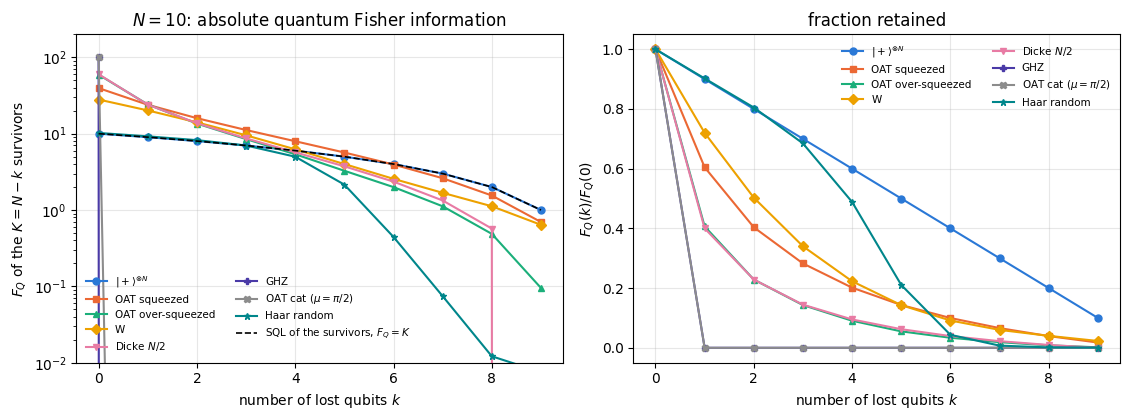

In [8]:
# ==============================================================================
# FIGURE 1: metrological power lost with the particles
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))
ks = np.arange(N_ZOO)
for j, name in enumerate(ZOO):
    axes[0].plot(ks, loss_curves[name], MARKERS[j] + "-", color=PALETTE[j], ms=5, label=ZOO_LBL[name])
    axes[1].plot(ks, loss_curves[name] / max(loss_curves[name][0], 1e-15), MARKERS[j] + "-",
                 color=PALETTE[j], ms=5, label=ZOO_LBL[name])
axes[0].plot(ks, N_ZOO - ks, "k--", lw=1.2, label=r"SQL of the survivors, $F_Q=K$")
axes[0].set_yscale("log"); axes[0].set_ylim(1e-2, 2 * N_ZOO ** 2)
axes[0].set_xlabel("number of lost qubits $k$")
axes[0].set_ylabel(r"$F_Q$ of the $K=N-k$ survivors")
axes[0].set_title(f"$N={N_ZOO}$: absolute quantum Fisher information")
axes[0].legend(fontsize=7.5, ncol=2, loc="lower left")
axes[1].set_xlabel("number of lost qubits $k$"); axes[1].set_ylabel(r"$F_Q(k)/F_Q(0)$")
axes[1].set_title("fraction retained"); axes[1].legend(fontsize=7.5, ncol=2)
fig.tight_layout(); plt.show()

The left panel is the one to read, because it is absolute: the dashed line is $F_Q=K$, the standard quantum limit of
whatever is left, and a probe is useful exactly as long as it stays above it.

The right panel — relative retention — is misleading. It ranks $\vert+\rangle^{\otimes N}$ as the most robust probe in
the zoo ($R=0.55$), which is correct and of no practical use: a probe that starts at the standard quantum limit ends
at the standard quantum limit, having gained nothing anywhere. This is why the loss budget $k_{\rm SQL}$ is the column to look at in the
table above.

> **Numerical practice.** Normalising a curve by its own initial value hides the only thing that matters when the
> initial values differ by two orders of magnitude. Plot the absolute quantity next to the relevant bound, and let
> the normalised version be the *second* panel, never the only one.

## 6. The shape of the loss curve, and where it comes from

Three shapes appear, and each has a structural cause.

**A cliff.** GHZ and the one-axis-twisting cat lose everything at $k=1$. Section 4.2 explained it: the lost qubit is a
perfect which-branch detector for a two-component superposition.

**A smooth decay.** The squeezed, over-squeezed, W and Dicke probes lose part of their QFI with every particle. In the
middle of the range each lost particle costs $30$–$45\%$ of what is left (the ratio $F_Q(k+1)/F_Q(k)$ in the table
lies between $0.56$ and $0.71$ for $2\le k\le6$); the first loss costs $60\%$ for the over-squeezed and Dicke
probes. The decay is not geometric: for the W and Dicke states it is the polynomial and hypergeometric law of
Eqs. (11)–(12). These states have many Schmidt components across any cut (Eq. 8), so the lost particles can only
partly tell which component the survivors are in.

**A Page-like shape.** The Haar-random probe follows the standard quantum limit of its survivors, $F_Q\approx K$, up
to $k=3$ and collapses once fewer than half of the qubits remain ($F_Q=2.2$ at $K=5$, $0.44$ at $K=4$). This is the
metrological Page curve measured in notebook 35: for $K<N/2$ the reduced state of a random state is close to
$\mathbb 1/2^K$ (Page), and a state close to the maximally mixed one carries almost no QFI for any generator. The
intact probe has $F_Q=10.22$, barely above $N=10$, so this robustness buys nothing — another reminder that "entangled"
and "useful" are different words.

It is tempting to look for the mechanism in the **entanglement spectrum** of the cut. For a generator that acts
inside $A$ — which, by Eq. (3), is the relevant case here — the substitution
$\langle m\vert\partial_\theta\rho_A\vert n\rangle=-i(\lambda_n-\lambda_m)\langle m\vert G_A\vert n\rangle$ turns
Eq. (2) into

$$F_Q=2\sum_{m,n}\frac{\left(\lambda_m-\lambda_n\right)^2}{\lambda_m+\lambda_n}
  \left\vert\langle m\vert G_A\vert n\rangle\right\vert^2, \tag{13}$$

which vanishes whenever the spectrum is flat on the support of the relevant matrix elements. So a flat $\rho_A$
*looks* like the culprit. The table below gives the counter-example explicitly.

In [9]:
# ==============================================================================
# STEP 4: the spectrum of rho_A at the first loss (k = 1), for every probe
# ==============================================================================
print(f"Eigenvalues of rho_A after losing ONE qubit (N = {N_ZOO}, K = {N_ZOO - 1}):\n")
print(f"{'probe':>14s} {'rank':>5s} {'S(rho_A) [bit]':>15s} {'F_Q(k=1)':>10s} | eigenvalues")
for name, psi in ZOO.items():
    lam = np.sort(np.array(schmidt_values(psi, range(N_ZOO - 1))) ** 2)[::-1]
    rank = int(np.sum(lam > 1e-12))
    Sv = float(-np.sum(lam[lam > 1e-16] * np.log2(lam[lam > 1e-16])))
    print(f"{name:>14s} {rank:5d} {Sv:15.4f} {loss_curves[name][1]:10.4f} | "
          + " ".join(f"{v:.4f}" for v in lam[:4]))

Eigenvalues of rho_A after losing ONE qubit (N = 10, K = 9):

         probe  rank  S(rho_A) [bit]   F_Q(k=1) | eigenvalues
         |+>^N     1          0.0000     9.0000 | 1.0000 0.0000
  OAT squeezed     2          0.4122    23.9048 | 0.9171 0.0829
  OAT over-sq.     2          0.9301    24.1271 | 0.6544 0.3456
             W     2          0.4690    20.1600 | 0.9000 0.1000
     Dicke N/2     2          1.0000    24.0000 | 0.5000 0.5000
           GHZ     2          1.0000     0.0000 | 0.5000 0.5000
       OAT cat     2          1.0000     0.0000 | 0.5000 0.5000
          Haar     2          0.9973     9.2227 | 0.5304 0.4696


Losing one qubit gives $\rho_A$ rank at most $2$, so this table is short and completely explicit — and it refutes the
spectral explanation. **Three probes have exactly the same spectrum $(0.5,0.5)$ and two very different answers.** GHZ
and the one-axis-twisting cat give $F_Q=0$; the half-filled Dicke state, with the *identical* pair of eigenvalues,
gives $F_Q=24.0$. The nearly flat Haar-random spectrum $(0.530,0.470)$ gives $F_Q=9.2$, and the over-squeezed state,
with a more mixed spectrum $(0.654,0.346)$ than the squeezed one $(0.917,0.083)$, keeps slightly *more*
($24.1$ against $23.9$).

Equation (13) says why. The prefactor $(\lambda_m-\lambda_n)^2/(\lambda_m+\lambda_n)$ vanishes for the two states
*inside* the support, but the sum also runs over the $2^K-2$ states with $\lambda_n=0$, where the prefactor is
$\lambda_m$, not zero. What decides is therefore the matrix element $\langle m\vert G_A\vert n\rangle$ out of the
support:

* for GHZ, $\rho_A$ is supported on $\vert0\rangle^{\otimes K}$ and $\vert1\rangle^{\otimes K}$, which are
  **eigenstates** of $G_A=J_z^A$ — every matrix element out of the support vanishes and $F_Q$ is exactly $0$;
* for the Dicke state, the support is spanned by neighbouring Dicke levels and $G_A=J_x^A$ connects them to levels
  *outside* the support ($\vert\langle D_9^3\vert J_x\vert D_9^4\rangle\vert^2=6$ by Eq. (10)), and Eq. (13) gives
  $2\cdot2\cdot2\cdot\tfrac12\cdot6=24$ — exactly the measured value.

So the mixedness of the survivors is not the mechanism. **The mechanism is whether the generator can still move the
state of the survivors**, which is a statement about the pair (state, generator), never about the state alone — the
same lesson notebook 29 drew for intact probes, now with a partial trace in front of it.

## 7. Magic: non-stabilizerness as a predictor of robustness

Entanglement entropy does not predict metrological usefulness (notebook 29) nor, as we just saw, loss robustness.
A natural next candidate is **magic** — the non-stabilizerness of the state, the resource that makes a circuit hard
to simulate classically. Notebook 27 defines the **stabilizer Rényi entropy**

$$M_\alpha(\psi)=\frac{1}{1-\alpha}\log_2\left(\frac{1}{2^N}\sum_{P\in\mathcal P_N}
   \left\vert\langle\psi\vert P\vert\psi\rangle\right\vert^{2\alpha}\right), \tag{14}$$

the Rényi entropy of the distribution $\Pi(P)=\langle P\rangle^2/2^N$ over all $4^N$ Pauli strings. $M_\alpha=0$ if
and only if $\vert\psi\rangle$ is a stabilizer state, and $M_2\le\log_2\left[(2^N+1)/2\right]$ (notebook 27,
Section 6.5). We use
$\alpha=2$ and the Walsh–Hadamard algorithm of notebook 27, which evaluates all $4^N$ Pauli expectation values in
$O(N4^N)$ instead of $O(8^N)$: writing $P=i^{\mathbf a\cdot\mathbf b}X^{\mathbf a}Z^{\mathbf b}$,

$$\langle P_{\mathbf{a},\mathbf{b}}\rangle=\text{phase}\times\sum_{\mathbf s}(-1)^{\mathbf b\cdot\mathbf s}\,
  \overline{\psi[\mathbf s\oplus\mathbf a]}\,\psi[\mathbf s]
  =\text{phase}\times\mathrm{WHT}_{\mathbf b}\!\left[f_{\mathbf a}\right],$$

so one Walsh–Hadamard transform delivers every $Z$-pattern for a given $X$-pattern at once.

In [10]:
# ==============================================================================
# STEP 5: the stabilizer Renyi entropy M_2 (Walsh-Hadamard algorithm of notebook 27)
# ==============================================================================
@partial(jax.jit, static_argnames=("N",))
def _pauli_moment_batch(flat, a_batch, two_alpha, N):
    """sum over a batch of X-patterns `a` of  sum_b |<P_{a,b}>|^(2 alpha).

    MATH   <P_{a,b}> = i^(a.b) * WHT_b[ f_a ],   f_a[s] = conj(psi[s XOR a]) psi[s];  |i^(a.b)| = 1.
    JAX    vmap over `a`; `flat[idx ^ a]` is a gather with a traced index, N is static (it fixes the shapes).
    """
    idx = jnp.arange(2 ** N)

    def for_a(a):
        f = (jnp.conj(flat[idx ^ a]) * flat).reshape((2,) * N)
        return jnp.sum(jnp.abs(_wht_all_axes(f)) ** two_alpha)

    return jnp.sum(jax.vmap(for_a)(a_batch))


def sre(psi, alpha=2.0, batch=256):
    """Stabilizer Renyi entropy M_alpha of a pure state -- Eq. (14).   COST O(N 4^N), memory O(batch 2^N)."""
    N = psi.ndim
    flat = psi.reshape(-1)
    batch = min(int(batch), 2 ** N)
    two_alpha = jnp.asarray(2.0 * alpha, dtype=RDTYPE)
    all_a = jnp.arange(2 ** N)
    total = jnp.zeros((), dtype=RDTYPE)
    for start in range(0, 2 ** N, batch):
        total = total + _pauli_moment_batch(flat, all_a[start:start + batch], two_alpha, N)
    return float(jnp.log2(total / 2 ** N) / (1.0 - alpha))


# --- CHECKPOINT: stabilizer states give exactly 0; a product of T|+> gives N log2(4/3) --------
LOG2_43 = float(np.log2(4 / 3))
t_plus = product_state("+" * 5)
for q in range(5):
    t_plus = apply_gate(t_plus, T, [q])
chk_magic = {"GHZ (stabilizer)": (ghz_state(5), 0.0), "|0>^N (stabilizer)": (zero_state(5), 0.0),
             "(T|+>)^5": (t_plus, 5 * LOG2_43)}
for name, (p, ref) in chk_magic.items():
    got = sre(p)
    print(f"  M_2[{name:20s}] = {got:+.10f}   expected {ref:.10f}   err {abs(got - ref):.1e}")
    assert abs(got - ref) < 1e4 * TOL
print(f"\n  (log2(4/3) = {LOG2_43:.6f} bit is the magic of one T gate on |+>; "
      f"upper bound at N=5 is {np.log2((2 ** 5 + 1) / 2):.4f} bit)")

  M_2[GHZ (stabilizer)    ] = +0.0000000000   expected 0.0000000000   err 1.3e-15
  M_2[|0>^N (stabilizer)  ] = -0.0000000000   expected 0.0000000000   err 0.0e+00
  M_2[(T|+>)^5            ] = +2.0751874964   expected 2.0751874964   err 4.9e-15

  (log2(4/3) = 0.415037 bit is the magic of one T gate on |+>; upper bound at N=5 is 4.0444 bit)


In [11]:
# ==============================================================================
# STEP 6: magic of the probe zoo, against robustness
# ==============================================================================
print(f"N = {N_ZOO}:  magic and loss robustness side by side "
      f"(upper bound M_2 <= {np.log2((2 ** N_ZOO + 1) / 2):.3f} bit)\n")
print(f"{'probe':>14s} {'M_2 [bit]':>10s} {'S(N/2) [bit]':>13s} {'F_Q(0)':>9s} {'R':>7s} {'k_SQL':>6s}")
zoo_magic = {}
for name, psi in ZOO.items():
    zoo_magic[name] = sre(psi)
    f0, _, R, budget, S_half = zoo_info[name]
    print(f"{name:>14s} {zoo_magic[name]:10.4f} {S_half:13.4f} {f0:9.3f} {R:7.3f} {budget:6d}")

m2 = np.array([zoo_magic[n] for n in ZOO])
Rv = np.array([zoo_info[n][2] for n in ZOO])
bud = np.array([zoo_info[n][3] for n in ZOO], dtype=float)
print(f"\nPearson correlation over the {len(ZOO)} probes:  corr(M_2, R) = {np.corrcoef(m2, Rv)[0, 1]:+.3f},"
      f"   corr(M_2, k_SQL) = {np.corrcoef(m2, bud)[0, 1]:+.3f}")

N = 10:  magic and loss robustness side by side (upper bound M_2 <= 9.001 bit)

         probe  M_2 [bit]  S(N/2) [bit]    F_Q(0)       R  k_SQL


         |+>^N     0.0000        0.0000    10.000   0.550      0
  OAT squeezed     1.9660        0.7967    39.535   0.286      5
  OAT over-sq.     4.3819        1.8081    59.343   0.199      3
             W     3.9658        1.0000    28.000   0.314      4
     Dicke N/2     2.9718        1.7830    60.000   0.200      3


           GHZ     0.0000        1.0000   100.000   0.100      0
       OAT cat     0.0000        1.0000   100.000   0.100      0
          Haar     8.0038        4.2628    10.222   0.414      2

Pearson correlation over the 8 probes:  corr(M_2, R) = +0.273,   corr(M_2, k_SQL) = +0.482


The table settles the question for the standard probes, and the answer is negative. Read the rows with $M_2=0$
first: $\vert+\rangle^{\otimes N}$, GHZ and the cat are all *exactly* stabilizer states, yet the product state has
the largest relative retention in the zoo ($R=0.55$) and the two cats have the smallest ($R=0.10$). Zero magic is
compatible with the best and with the worst behaviour. At the other end, the Haar-random state carries $8.00$ bit of
magic (the upper bound is $9.00$) and has a loss budget of $2$, but it starts at $F_Q=10.22$, barely above the
standard quantum limit, so the budget measures how slowly it falls towards $K$, not an advantage. The best probe in
the zoo, the squeezed state, sits at a modest $M_2=1.97$.

The Pearson correlations printed above are positive ($0.27$ and $0.48$), but with eight hand-picked probes they are
not a statistical statement at all; the rows show that the ranking is set by which *family* a state belongs to
rather than by $M_2$. **Magic is not a robustness measure**, and there is no reason it should be: $M_2$ measures how
far the state is from the set of stabilizer states, a property of the whole Pauli spectrum, while loss robustness
asks the much more specific question of Section 6, whether the generator can still move the survivors. Section 10
uses a controlled family to find what magic does change: the *shape* of the loss curve.

## 8. Defending against loss: a phase imprinted, then encoded

So far the probe was prepared, the phase imprinted, and the particles lost. Now insert a step. Consider the pipeline

$$\vert\mathrm{GHZ}\rangle\ \xrightarrow{\ e^{-i\theta J_z}\ }\ \vert\psi_\theta\rangle
  \ \xrightarrow{\ V\ }\ V\vert\psi_\theta\rangle\ \xrightarrow{\ \text{lose }k\text{ qubits}\ }\ \rho_A(\theta), \tag{15}$$

where $V$ is a circuit of our choosing — an *encoder*. Physically: the phase is acquired during a short interrogation,
and then the register is encoded for storage or transport, during which particles go missing.

Two things must be said straight away.

* **The full-system QFI cannot change.** $F_Q\left[V\psi_\theta, VJ_zV^\dagger\right]=F_Q\left[\psi_\theta,J_z\right]=N^2$
  for any unitary $V$: unitaries do not create or destroy information. The encoder can only change **where** the
  information sits, and therefore how it survives a partial trace. (Notebook 35 makes the complementary point: for a
  *fixed* generator, scrambling collapses the QFI to $\approx N$; the invariance holds only if the generator is
  transformed along with the state.)
* **The generator becomes non-local.** After the encoder the parameter is generated by $G_V=VJ_zV^\dagger$, which for
  a depth-$L$ circuit is a sum of Pauli strings of growing support. This is exactly the case Eq. (3) does not cover,
  and why we built `block_qfi` around a tangent vector: we simply propagate $\vert\phi\rangle=J_z\vert\mathrm{GHZ}\rangle$
  through the same circuit, since $V\left(J_z\vert\psi\rangle\right)=G_V\left(V\vert\psi\rangle\right)$.

### 8.1 The encoded probe is a two-dimensional code

The state before the encoder is

$$\vert\psi_\theta\rangle=\frac{1}{\sqrt2}\left(e^{-iN\theta/2}\vert0\rangle^{\otimes N}
  +e^{+iN\theta/2}\vert1\rangle^{\otimes N}\right),$$

because $J_z\vert0\rangle^{\otimes N}=+\tfrac N2\vert0\rangle^{\otimes N}$ and
$J_z\vert1\rangle^{\otimes N}=-\tfrac N2\vert1\rangle^{\otimes N}$: the whole parameter dependence is a single
relative phase $\varphi=N\theta$. After the encoder,

$$V\vert\psi_\theta\rangle=\frac{1}{\sqrt2}\left(e^{-i\varphi/2}\vert\bar0\rangle+e^{+i\varphi/2}\vert\bar1\rangle\right),
  \qquad \vert\bar0\rangle=V\vert0\rangle^{\otimes N},\quad\vert\bar1\rangle=V\vert1\rangle^{\otimes N}. \tag{16}$$

Two orthonormal **codewords** carrying a logical phase. Tracing out the lost set $B$,

$$\rho_A(\varphi)=\tfrac12\left(\rho_{\bar0}+\rho_{\bar1}
  +e^{i\varphi}\,C+e^{-i\varphi}\,C^\dagger\right),\qquad
  C=\mathrm{Tr}_B\left(\vert\bar1\rangle\langle\bar0\vert\right), \tag{17}$$

so $\partial_\varphi\rho_A=\tfrac{i}{2}\left(e^{i\varphi}C-e^{-i\varphi}C^\dagger\right)$ and **the entire
$\varphi$-dependence sits in the codeword coherence $C$**. If $C=0$ the survivors know nothing:
$F_Q=0$. And because $F_{Q,\theta}=N^2F_{Q,\varphi}$ (chain rule, $\varphi=N\theta$), the Heisenberg value is
recovered exactly when $F_{Q,\varphi}=1$, i.e. when the logical qubit is *perfectly* coherent after the erasure.

There is a standard name for the situation in which the survivors keep *everything*. The loss of the set $B$ is a
**quantum erasure**, and it is correctable exactly when the lost qubits carry no information about which codeword was
sent, i.e. when

$$\mathrm{Tr}_A\left(\vert\bar i\rangle\langle\bar j\vert\right)=\delta_{ij}\,\sigma_B
  \quad\text{for a fixed }\sigma_B, \tag{18}$$

which is the Knill–Laflamme error-correction condition specialised to the operator algebra of $B$ (Knill and Laflamme
1997; the erasure formulation is Grassl, Beth and Pellizzari 1997). Equation (18) with $i=j$ says that the two
codewords are *indistinguishable* from $B$ alone, and with $i\neq j$ that $B$ holds no coherence between them; when
both hold, the logical qubit, and with it the coherence $C$ of Eq. (17), can be recovered from $A$. The un-encoded GHZ state ($V=\mathbb 1$) violates it maximally as soon as one qubit is lost:
$\mathrm{Tr}_A\left(\vert\bar0\rangle\langle\bar0\vert\right)=\vert0\rangle\langle0\vert$ against
$\vert1\rangle\langle1\vert$ — one look at the lost qubit and the branch is known. That is Eq. (6). A good encoder is
one that does not let this happen.

In [12]:
# ==============================================================================
# STEP 7: encoders. A Clifford layer, and a family with tunable magic.
# ==============================================================================
def cnot_brickwork(psi):
    """One brick-wall layer of CNOTs: even bonds (0,1),(2,3),... then odd bonds (1,2),(3,4),..."""
    N = psi.ndim
    for q in range(0, N - 1, 2):
        psi = apply_gate(psi, CNOT, [q, q + 1])
    for q in range(1, N - 1, 2):
        psi = apply_gate(psi, CNOT, [q, q + 1])
    return psi


def clifford_layer(psi):
    """A CLIFFORD encoding layer: CNOTs on even bonds, H.S on every qubit, CNOTs on odd bonds, H.S again.
    Every gate maps Pauli strings to Pauli strings, so codewords stay stabilizer states and M_2 stays 0."""
    N = psi.ndim
    for q in range(0, N - 1, 2):
        psi = apply_gate(psi, CNOT, [q, q + 1])
    for q in range(N):
        psi = apply_gate(apply_gate(psi, H, [q]), S, [q])
    for q in range(1, N - 1, 2):
        psi = apply_gate(psi, CNOT, [q, q + 1])
    for q in range(N):
        psi = apply_gate(apply_gate(psi, H, [q]), S, [q])
    return psi


def magic_layer(psi, angle):
    """Encoding layer with TUNABLE magic:  Ry(angle) on every qubit, then the CNOT brick wall.
    angle = 0, pi/2, pi, 3pi/2 make Ry a Clifford gate (M_2 = 0); angle = pi/4 is maximally non-Clifford."""
    for q in range(psi.ndim):
        psi = apply_gate(psi, ry(angle), [q])
    return cnot_brickwork(psi)


def encode_pipeline(N, layer, L):
    """Run pipeline (15) at theta = 0: |GHZ> -> imprint with J_z -> L encoding layers.
    Returns (psi, phi) with phi = G_V psi, the tangent vector of the encoded family.
    The SAME circuit is applied to both, because V (J_z |psi>) = (V J_z V^dag) (V |psi>)."""
    return encode_pipeline_theta(N, layer, L, 0.0)


def encode_pipeline_theta(N, layer, L, theta):
    """Pipeline (15) at a finite phase: |GHZ> -> exp(-i theta J_z) -> L layers; returns (psi_theta, G_V psi_theta).

    MATH   exp(-i theta J_z) = prod_q exp(-i theta Z_q / 2);  the tangent vector is V J_z |psi_theta>.
    """
    U = jnp.cos(theta / 2) * I2 - 1j * jnp.sin(theta / 2) * Z
    psi = ghz_state(N)
    for q in range(N):
        psi = apply_gate(psi, U, [q])
    phi = collective_tangent(psi, (0, 0, 1))          # J_z |psi_theta>
    for _ in range(L):
        psi, phi = layer(psi), layer(phi)
    return psi, phi


# --- CHECKPOINT: the encoder cannot change the full-system QFI (it is still N^2) ---------
N_ENC = 10
print(f"N = {N_ENC}:  F_Q of the FULL encoded state (no loss) -- must stay at N^2 = {N_ENC ** 2}\n")
err_inv = 0.0
for lname, layer in (("Clifford", clifford_layer), ("Ry(pi/4)+CNOT", partial(magic_layer, angle=np.pi / 4))):
    vals = []
    for L in range(5):
        psi, phi = encode_pipeline(N_ENC, layer, L)
        vals.append(float(block_qfi(psi, phi, range(N_ENC))))
    err_inv = max(err_inv, max(abs(v - N_ENC ** 2) for v in vals))
    print(f"  {lname:16s} L = 0..4: " + " ".join(f"{v:9.5f}" for v in vals))
print(f"\n  worst deviation from N^2: {err_inv:.2e}")
assert err_inv < 1e4 * TOL

# --- CHECKPOINT: Eq. (4) for a NON-LOCAL generator, against jax.jacfwd of rho_A(theta) -------
# (checkpoint 1 tested Eq. (4) only for collective generators; here G_V = V J_z V^dag is a many-body operator)
print("\n  block_qfi with the propagated tangent vector against jax.jacfwd of Tr_B[ V e^{-i theta J_z}|GHZ> ]:")
err_nl = 0.0
for lname, layer, L, k in (("Clifford", clifford_layer, 3, 5), ("Clifford", clifford_layer, 3, 6),
                           ("Ry(pi/4)+CNOT", partial(magic_layer, angle=np.pi / 4), 3, 3)):
    K = N_ENC - k
    psi, phi = encode_pipeline(N_ENC, layer, L)
    a = float(block_qfi(psi, phi, range(K)))

    def rho_A_enc(th, layer=layer, L=L, K=K):
        return rdm(encode_pipeline_theta(N_ENC, layer, L, th)[0], range(K))

    d = float(qfi_from_derivative(rho_A_enc(0.0), jax.jacfwd(rho_A_enc)(0.0)))
    err_nl = max(err_nl, abs(a - d))
    print(f"  {lname:16s} L={L} k={k}:  tangent vector {a:10.6f}   jacfwd {d:10.6f}")
print(f"  worst discrepancy: {err_nl:.2e}")
assert err_nl < 1e4 * TOL

N = 10:  F_Q of the FULL encoded state (no loss) -- must stay at N^2 = 100



  Clifford         L = 0..4: 100.00000 100.00000 100.00000 100.00000 100.00000


  Ry(pi/4)+CNOT    L = 0..4: 100.00000 100.00000 100.00000 100.00000 100.00000

  worst deviation from N^2: 1.59e-12

  block_qfi with the propagated tangent vector against jax.jacfwd of Tr_B[ V e^{-i theta J_z}|GHZ> ]:


  Clifford         L=3 k=5:  tangent vector 100.000000   jacfwd 100.000000


  Clifford         L=3 k=6:  tangent vector   0.000000   jacfwd   0.000000


  Ry(pi/4)+CNOT    L=3 k=3:  tangent vector   9.386526   jacfwd   9.386526
  worst discrepancy: 2.13e-14


The invariance holds to machine precision, as it must: the encoder moves information around, it does not add any.
Everything that follows is therefore a statement about *where* the information went.

## 9. The Clifford encoder: an all-or-nothing erasure threshold

Take the Clifford encoder first. Both codewords $\vert\bar0\rangle=V\vert0\rangle^{\otimes N}$ and
$\vert\bar1\rangle=V\vert1\rangle^{\otimes N}$ are then **stabilizer states**: the code is a stabilizer code with one
logical qubit. Section 9.1 derives that the QFI of the survivors can then take only the values $0$ and $N^2$. We first
measure it, together with the norm of the coherence $C$ of Eq. (17), for the loss of the last $k$ qubits.

In [13]:
# ==============================================================================
# STEP 8: QFI of the survivors, and the codeword coherence, versus encoder depth
# ==============================================================================
def codeword_coherence(N, layer, L, k):
    """||C||_F with C = Tr_B(|1bar><0bar|), B = the last k qubits -- the object of Eq. (17)."""
    a, b = basis_state([0] * N), basis_state([1] * N)
    for _ in range(L):
        a, b = layer(a), layer(b)
    K = N - k
    A = a.reshape(2 ** K, -1)
    B = b.reshape(2 ** K, -1)
    return float(jnp.linalg.norm(B @ A.conj().T))


L_MAX_C = 6
print(f"N = {N_ENC}, CLIFFORD encoder.   F_Q of the survivors  (Heisenberg = {N_ENC ** 2}, SQL of survivors = N-k)\n")
print(f"{'L':>3s} | " + " ".join(f"k={k:<7d}" for k in range(N_ENC)))
cliff_tab = {}
for L in range(L_MAX_C + 1):
    psi, phi = encode_pipeline(N_ENC, clifford_layer, L)
    cliff_tab[L] = np.array([float(block_qfi(psi, phi, range(N_ENC - k))) for k in range(N_ENC)])
    print(f"{L:3d} | " + " ".join(f"{v:8.3f} " for v in cliff_tab[L]))

print(f"\nCodeword coherence ||C||_F of Eq. (17) for the same circuits:\n")
print(f"{'L':>3s} | " + " ".join(f"k={k:<7d}" for k in range(N_ENC)))
coh_tab = {}
for L in range(L_MAX_C + 1):
    coh_tab[L] = np.array([codeword_coherence(N_ENC, clifford_layer, L, k) for k in range(N_ENC)])
    print(f"{L:3d} | " + " ".join(f"{v:8.4f} " for v in coh_tab[L]))

kmax_cliff = [int(np.max(np.nonzero(cliff_tab[L] > 1e-9)[0])) for L in range(L_MAX_C + 1)]
print(f"\nlargest correctable erasure k* (last k qubits): " +
      " ".join(f"L={L}: {kmax_cliff[L]}" for L in range(L_MAX_C + 1)))

N = 10, CLIFFORD encoder.   F_Q of the survivors  (Heisenberg = 100, SQL of survivors = N-k)

  L | k=0       k=1       k=2       k=3       k=4       k=5       k=6       k=7       k=8       k=9      
  0 |  100.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000 
  1 |  100.000   100.000   100.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000 
  2 |  100.000   100.000   100.000   100.000   100.000     0.000     0.000     0.000     0.000     0.000 


  3 |  100.000   100.000   100.000   100.000   100.000   100.000     0.000     0.000     0.000     0.000 
  4 |  100.000   100.000   100.000   100.000   100.000     0.000     0.000     0.000     0.000     0.000 


  5 |  100.000   100.000   100.000   100.000     0.000     0.000     0.000     0.000     0.000     0.000 


  6 |  100.000   100.000   100.000   100.000     0.000     0.000     0.000     0.000     0.000     0.000 

Codeword coherence ||C||_F of Eq. (17) for the same circuits:

  L | k=0       k=1       k=2       k=3       k=4       k=5       k=6       k=7       k=8       k=9      


  0 |   1.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000 


...

  2 |   1.0000    1.0000    1.0000    0.7071    0.7071    0.0000    0.0000    0.0000    0.0000    0.0000 


  3 |   1.0000    0.7071    0.7071    0.7071    0.5000    0.5000    0.0000    0.0000    0.0000    0.0000 


  4 |   1.0000    0.7071    0.5000    0.5000    0.3536    0.0000    0.0000    0.0000    0.0000    0.0000 


  5 |   1.0000    0.7071    0.5000    0.3536    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000 


  6 |   1.0000    0.7071    0.5000    0.3536    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000 

largest correctable erasure k* (last k qubits): L=0: 0 L=1: 2 L=2: 4 L=3: 5 L=4: 4 L=5: 3 L=6: 3


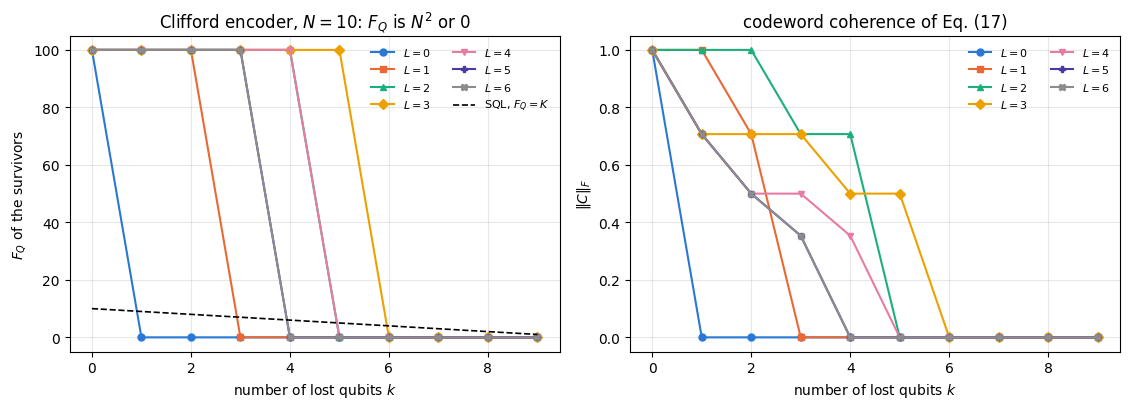

In [14]:
# ==============================================================================
# FIGURE 2: the erasure threshold of the Clifford-encoded probe
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2))
for L in range(L_MAX_C + 1):
    axes[0].plot(np.arange(N_ENC), cliff_tab[L], MARKERS[L % 8] + "-", color=PALETTE[L % 8],
                 ms=5, label=f"$L={L}$")
    axes[1].plot(np.arange(N_ENC), coh_tab[L], MARKERS[L % 8] + "-", color=PALETTE[L % 8], ms=5, label=f"$L={L}$")
axes[0].plot(np.arange(N_ENC), N_ENC - np.arange(N_ENC), "k--", lw=1.2, label=r"SQL, $F_Q=K$")
axes[0].set_xlabel("number of lost qubits $k$"); axes[0].set_ylabel(r"$F_Q$ of the survivors")
axes[0].set_title(f"Clifford encoder, $N={N_ENC}$: $F_Q$ is $N^2$ or $0$")
axes[0].legend(fontsize=8, ncol=2)
axes[1].set_xlabel("number of lost qubits $k$"); axes[1].set_ylabel(r"$\Vert C\Vert_F$")
axes[1].set_title("codeword coherence of Eq. (17)"); axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout(); plt.show()

The left panel is a staircase: $F_Q$ is either exactly $N^2=100$ or exactly $0$, never in between. For the loss of
the last $k$ qubits the Clifford-encoded GHZ probe behaves as an **erasure code**: it either keeps the full Heisenberg
value or loses everything. The unencoded case $L=0$ fails at $k=1$; one layer protects against the loss of the last
two qubits, two and three layers against the last four and five.

The right panel shows $\Vert C\Vert_F$, which takes the values $1,\ 1/\sqrt2,\ 1/2,\ 1/\sqrt8$, and $F_Q$ is non-zero
exactly where $\Vert C\Vert_F>0$. A *decreasing* $\Vert C\Vert_F$ costs no QFI: at $L=3$ the coherence drops to $0.707$
at $k=1$ and the QFI is still exactly $100$. The reason is the structure of a correctable erasure: when Eq. (18)
holds, a unitary $U_A$ on the survivors brings both codewords to the form
$U_A\left(\vert c\rangle_{\rm L}\otimes\vert\chi\rangle\right)$, with one logical qubit and a codeword-independent
remainder $\vert\chi\rangle$ shared with $B$. Then $C=U_A\left(\vert1\rangle\langle0\vert_{\rm L}\otimes\sigma\right)U_A^\dagger$
with $\sigma=\mathrm{Tr}_B\vert\chi\rangle\langle\chi\vert$, so $\Vert C\Vert_F=\Vert\sigma\Vert_F$, which is
$2^{-r/2}$ for a flat $\sigma$ of rank $2^r$ — the powers of $\sqrt2$ in the table — while the logical qubit, and with
it $F_{Q,\varphi}=1$, is untouched.

The protection depth $k^*$ for the last $k$ qubits is **not monotone** in $L$: at $N=10$ we measure
$k^*=0,2,4,5,4,3,3$ for $L=0,\dots,6$. Sections 9.1 and 9.2 explain the threshold and show that it depends on *which*
qubits are lost: the last $k$ qubits are one erasure pattern among $\binom{N}{k}$.

> **Physics insight.** This appears to contradict the statement that GHZ states are useless under loss. But the phase
> in Eq. (15) is imprinted **before** the encoder. The code protects information that the probe already has; it does
> not help the probe acquire it. Section 11 measures the cost on the acquisition side.

### 9.1 The three-case rule for stabilizer codes

For a stabilizer code the threshold can be derived. The code space spanned by $\vert\bar0\rangle,\vert\bar1\rangle$
has the **logical operators** $\bar Z=VZ_qV^\dagger$ (any $q$), $\bar X=VX^{\otimes N}V^\dagger$ and
$\bar Y=i\bar X\bar Z$, each defined up to multiplication by stabilizers $VZ_qZ_{q'}V^\dagger$. Expand the operators
of Eq. (18) in Pauli strings $P_B$ supported on $B$; the coefficient of $P_B$ is $\langle\bar j\vert P_B\vert\bar i\rangle$.
A Pauli string either anticommutes with some stabilizer (then every such matrix element vanishes), or is $\pm$ a
stabilizer (then it is the same number for both codewords and zero between them), or is $\pm$ a logical operator.
Hence **Eq. (18) fails exactly when some logical operator has a representative supported inside $B$.**

The logical operators that the survivors $A$ can still measure are those with a representative inside $A$. For one
logical qubit there are three possibilities: all of $\bar X,\bar Y,\bar Z$ (the erasure is correctable), none of
them, or exactly one $\bar P$, which is then also the one supported on $B$. In the last case $\rho_A$ depends on the
phase only through $\langle\bar P\rangle$, a two-outcome measurement with probabilities $(1\pm\langle\bar P\rangle)/2$ and
classical Fisher information $F_\varphi=(\partial_\varphi\langle\bar P\rangle)^2/(1-\langle\bar P\rangle^2)$. In the
state of Eq. (16), $\langle\bar X\rangle=\cos\varphi$, $\langle\bar Y\rangle=\sin\varphi$, $\langle\bar Z\rangle=0$. So,
with $F_{Q,\theta}=N^2F_{Q,\varphi}$,

| what $A$ can measure | $F_Q$ at $\theta=0$ | $F_Q$ at generic $\theta$ |
|---|---|---|
| $\bar X,\bar Y,\bar Z$ (Eq. 18 holds) | $N^2$ | $N^2$ |
| nothing, or only $\bar Z$ | $0$ | $0$ |
| only $\bar X$ | $0$ | $N^2$ |
| only $\bar Y$ | $N^2$ | $N^2$ |

Every entry is $0$ or $N^2$: that is the staircase. The table also shows two subtleties. Only $\bar X$ gives a QFI that
jumps from $0$ at $\theta=0$ to $N^2$ at any other $\theta$, because $\partial_\varphi\cos\varphi=0$ at $\varphi=0$ (the
reduced-state QFI is not $\theta$-independent here, as anticipated in Section 3.3). Only $\bar Y$ gives the full
Heisenberg value although the erasure is *not* correctable: one logical observable suffices to estimate a phase near a
known working point. So "$F_Q=N^2$ at $\theta=0$" and "the erasure is correctable" are different statements.

A representative of $\bar P$ lies inside $B$ exactly when the two eigenstates $\bar P=\pm1$ have different reduced
states on $B$ (a stabilizer or an anticommuting string has the same expectation in both, and the other two logical
operators have zero expectation in both). This gives a direct numerical test of every row of the table.

### 9.2 Every erasure pattern

Particles are not lost in a prescribed order. The next cell goes through **every** set $B$ of $k\le3$ lost qubits for
every depth, determines which logical operators are supported on $B$, predicts $F_Q$ at $\theta=0$ and at
$\theta=0.3$ from the table, and compares with `block_qfi`.

In [15]:
# ==============================================================================
# STEP 8b: all erasure patterns of size k <= 3, Eq. (18), and the three-case rule
# ==============================================================================
from itertools import combinations
from math import comb

K_PAT = 3                                   # largest erasure size scanned (C(10,1)+C(10,2)+C(10,3) = 175 patterns)
THETA_1 = 0.3                               # a generic phase, phi = N theta = 3


def reduced_on(v, lost):
    """Reduced density matrix of the qubits `lost` (rows/columns in the order of `lost`), NumPy, O(2^N 2^k)."""
    keep = tuple(q for q in range(v.ndim) if q not in lost)
    M = np.transpose(v, keep + tuple(lost)).reshape(2 ** len(keep), -1)
    return M.T @ M.conj()


def logicals_on(c0, c1, lost, tol=1e-9):
    """Set of logical operators of the code {c0, c1} with a representative inside `lost`.

    MATH   P in {X, Y, Z} is supported on B  <=>  Tr_A |P=+1><P=+1| != Tr_A |P=-1><P=-1|,
           with eigenstates  Z: c0, c1;  X: (c0 +- c1)/sqrt2;  Y: (c0 +- i c1)/sqrt2   (Section 9.1).
    """
    eig = {"Z": (c0, c1), "X": ((c0 + c1) / np.sqrt(2), (c0 - c1) / np.sqrt(2)),
           "Y": ((c0 + 1j * c1) / np.sqrt(2), (c0 - 1j * c1) / np.sqrt(2))}
    return {P for P, (u, w) in eig.items() if np.abs(reduced_on(u, lost) - reduced_on(w, lost)).max() > tol}


print(f"N = {N_ENC}, CLIFFORD encoder, all erasure patterns with k <= {K_PAT}.")
print(f"Columns per k:  #patterns satisfying Eq. (18) / #with F_Q = N^2 at theta = 0 / #at theta = {THETA_1} "
      f"(out of C(N,k)).\n")
print(f"{'L':>3s} | " + " | ".join(f"{'k=' + str(k):^17s}" for k in range(1, K_PAT + 1))
      + " | guaranteed k | last-k k*")
dev_rule, n_only = 0.0, {"X": 0, "Y": 0}
pattern_tab = {}
for L in range(L_MAX_C + 1):
    c0, c1 = basis_state([0] * N_ENC), basis_state([1] * N_ENC)
    for _ in range(L):
        c0, c1 = clifford_layer(c0), clifford_layer(c1)
    c0, c1 = np.asarray(c0), np.asarray(c1)
    p0, f0 = encode_pipeline(N_ENC, clifford_layer, L)
    p1, f1 = encode_pipeline_theta(N_ENC, clifford_layer, L, THETA_1)
    counts = []
    for k in range(1, K_PAT + 1):
        n18 = nF0 = nF1 = 0
        for lost in combinations(range(N_ENC), k):
            keep = [q for q in range(N_ENC) if q not in lost]
            sup = logicals_on(c0, c1, lost)
            pred0 = N_ENC ** 2 if sup in (set(), {"Y"}) else 0.0              # table of Section 9.1
            pred1 = N_ENC ** 2 if sup in (set(), {"X"}, {"Y"}) else 0.0
            F0 = float(block_qfi(p0, f0, keep))
            F1 = float(block_qfi(p1, f1, keep))
            dev_rule = max(dev_rule, abs(F0 - pred0), abs(F1 - pred1))
            n18 += (not sup); nF0 += F0 > N_ENC ** 2 / 2; nF1 += F1 > N_ENC ** 2 / 2
            if len(sup) == 1 and sup != {"Z"}:
                n_only[next(iter(sup))] += 1
        counts.append((n18, nF0, nF1))
    # guaranteed protection: the largest k such that EVERY pattern of size <= k satisfies Eq. (18)
    full = [counts[k - 1][0] == comb(N_ENC, k) for k in range(1, K_PAT + 1)]
    k_guar = next((k for k in range(K_PAT) if not full[k]), K_PAT)
    pattern_tab[L] = (counts, k_guar)
    print(f"{L:3d} | " + " | ".join(f"{a:4d} {b:4d} {c:4d}  " for a, b, c in counts)
          + f" | {k_guar:12d} | {kmax_cliff[L]:9d}")

print(f"\npatterns where A keeps only X-bar: {n_only['X']},  only Y-bar: {n_only['Y']}")
print(f"worst deviation of block_qfi from the three-case rule (both theta): {dev_rule:.2e}")
assert dev_rule < 1e4 * TOL

# --- the magic encoder is not a stabilizer code: its loss curve depends on theta smoothly -------------
pm0, fm0 = encode_pipeline(N_ENC, partial(magic_layer, angle=np.pi / 4), 6)
pm1, fm1 = encode_pipeline_theta(N_ENC, partial(magic_layer, angle=np.pi / 4), 6, THETA_1)
cm0 = np.array([float(block_qfi(pm0, fm0, range(N_ENC - k))) for k in range(N_ENC)])
cm1 = np.array([float(block_qfi(pm1, fm1, range(N_ENC - k))) for k in range(N_ENC)])
print(f"\nRy(pi/4)+CNOT, L = 6, last k lost:  F_Q(theta=0)   = " + " ".join(f"{v:6.2f}" for v in cm0))
print(f"                                    F_Q(theta={THETA_1}) = " + " ".join(f"{v:6.2f}" for v in cm1))

N = 10, CLIFFORD encoder, all erasure patterns with k <= 3.
Columns per k:  #patterns satisfying Eq. (18) / #with F_Q = N^2 at theta = 0 / #at theta = 0.3 (out of C(N,k)).

  L |        k=1        |        k=2        |        k=3        | guaranteed k | last-k k*


  0 |    0    0    0   |    0    0    0   |    0    0    0   |            0 |         0


  1 |    9    9    9   |   32   32   32   |   56   56   56   |            0 |         2


  2 |   10   10   10   |   41   43   43   |   90  102  102   |            1 |         4


  3 |   10   10   10   |   44   44   45   |  103  105  117   |            1 |         5


  4 |   10   10   10   |   45   45   45   |  114  114  115   |            2 |         4


  5 |   10   10   10   |   45   45   45   |  115  116  117   |            2 |         3


  6 |   10   10   10   |   44   45   45   |  108  118  120   |            1 |         3

patterns where A keeps only X-bar: 17,  only Y-bar: 28
worst deviation of block_qfi from the three-case rule (both theta): 3.95e-12



Ry(pi/4)+CNOT, L = 6, last k lost:  F_Q(theta=0)   = 100.00  80.43  79.16  43.64  39.56  14.31   5.31   0.63   0.02   0.00
                                    F_Q(theta=0.3) = 100.00  80.43  79.21  42.92  38.23  14.54   5.22   0.64   0.03   0.00


The three-case rule of Section 9.1 predicts `block_qfi` for all $7\times175$ patterns, at both phases, to machine
precision. The test has teeth: the naive rule "$F_Q=N^2$ exactly when Eq. (18) holds" is wrong by $N^2$ on the $28$
patterns where $A$ keeps only $\bar Y$ (at both phases) and on the $17$ where it keeps only $\bar X$ (at
$\theta=0.3$). Three conclusions follow.

* **The protection depends on which qubits are lost.** One Clifford layer protects the last two qubits, but the loss
  of one particular *single* qubit is already fatal (9 of 10 single losses are correctable). The *guaranteed*
  protection — the largest $k$ for which every pattern of $k$ losses satisfies Eq. (18) — is $0,0,1,1,2,2,1$ for
  $L=0,\dots,6$, well below the last-block values $0,2,4,5,4,3,3$. It is still not monotone in $L$ ($L=6$ is worse
  than $L=5$): a deeper circuit is not automatically a better code.
* **The fraction of correctable patterns grows with depth up to $L=5$.** For $k=3$ it is $0,56,90,103,114,115$ and
  $108$ out of $120$. For random losses this fraction, not the last-block threshold, is what an experiment sees.
* **$F_Q=N^2$ at $\theta=0$ is not the same as correctability**, in both directions predicted by the table: patterns
  in which $A$ keeps only $\bar Y$ give $N^2$ although Eq. (18) fails, and patterns in which $A$ keeps only $\bar X$
  give $0$ at $\theta=0$ and $N^2$ at $\theta=0.3$. For the last-$k$ blocks of Section 9 neither case occurs, which is
  why the staircase there coincides with Eq. (18).

The non-Clifford encoder is not a stabilizer code, and its loss curve depends on $\theta$ in a smooth way: the last two
lines of the output differ from $k=2$ on, by up to $1.3$ at $k=4$. All loss curves of Sections 9–11 are evaluated at $\theta=0$.

## 10. Tuning the magic of the encoder

The `magic_layer` family $\mathrm{Ry}(a)^{\otimes N}$ followed by the same CNOT brick wall has one knob. At
$a=0,\pi/2,\pi$ the rotation $\mathrm{Ry}(a)$ is a **Clifford** gate, so the encoded state is a stabilizer state and
$M_2=0$; among single-qubit $\mathrm{Ry}$ rotations, $a=\pi/4$ produces the largest magic ($\mathrm{Ry}(\pi/4)\vert0\rangle$
has $M_2=\log_2(4/3)$, the same as $T\vert+\rangle$). The circuit topology, the gate count and the entangling gates are
identical along the whole family; only the single-qubit angle changes. This is the most controlled comparison
available, but the angle changes the magic, the entanglement and the spreading of the generator at the same time.
(The $a=0$ member is a pure CNOT circuit, a different Clifford encoder from the one of Section 9.)

In [16]:
# ==============================================================================
# STEP 9: loss curves along the tunable-magic encoder family
# ==============================================================================
L_MAGIC = 8                              # encoder depth, fixed along the family
ANGLES = np.array([0.0, 0.0625, 0.125, 0.1875, 0.25, 0.3125, 0.375, 0.4375, 0.5]) * np.pi

print(f"N = {N_ENC}, encoder = [Ry(a) on every qubit + CNOT brick wall] x {L_MAGIC}\n")
print(f"{'a/pi':>7s} {'M_2 [bit]':>10s} {'S(N/2)':>8s} {'R':>7s} {'k_1/2':>6s} | F_Q(k)/N^2")
magic_tab, magic_m2 = {}, {}
for a in ANGLES:
    psi, phi = encode_pipeline(N_ENC, partial(magic_layer, angle=a), L_MAGIC)
    c = np.array([float(block_qfi(psi, phi, range(N_ENC - k))) for k in range(N_ENC)])
    magic_tab[a] = c
    magic_m2[a] = sre(psi)
    khalf = max([k for k in range(N_ENC) if c[k] > 0.5 * c[0]], default=0)
    print(f"{a / np.pi:7.4f} {magic_m2[a]:10.4f} "
          f"{float(entanglement_entropy(psi, range(N_ENC // 2))):8.3f} "
          f"{np.mean(c / c[0]):7.4f} {khalf:6d} | " + " ".join(f"{v:5.2f}" for v in c / N_ENC ** 2))

N = 10, encoder = [Ry(a) on every qubit + CNOT brick wall] x 8

   a/pi  M_2 [bit]   S(N/2)       R  k_1/2 | F_Q(k)/N^2


 0.0000     0.0000    1.000  0.3000      2 |  1.00  1.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00


 0.0625     4.8329    2.191  0.2049      0 |  1.00  0.42  0.31  0.17  0.10  0.05  0.01  0.00  0.00  0.00


 0.1250     6.8141    3.262  0.2676      0 |  1.00  0.48  0.45  0.35  0.27  0.11  0.02  0.00  0.00  0.00


 0.1875     7.1559    3.960  0.3795      3 |  1.00  0.74  0.73  0.58  0.50  0.19  0.04  0.01  0.00  0.00


 0.2500     7.1989    4.101  0.4705      4 |  1.00  0.97  0.95  0.77  0.68  0.25  0.07  0.01  0.00  0.00


 0.3125     7.1809    4.020  0.5148      4 |  1.00  0.99  0.98  0.91  0.80  0.34  0.11  0.01  0.00  0.00


 0.3750     6.9848    3.575  0.4642      4 |  1.00  0.95  0.86  0.73  0.63  0.35  0.11  0.01  0.00  0.00


 0.4375     4.0822    2.465  0.2394      1 |  1.00  0.58  0.47  0.15  0.12  0.06  0.01  0.00  0.00  0.00


 0.5000     0.0000    1.000  0.1000      0 |  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00


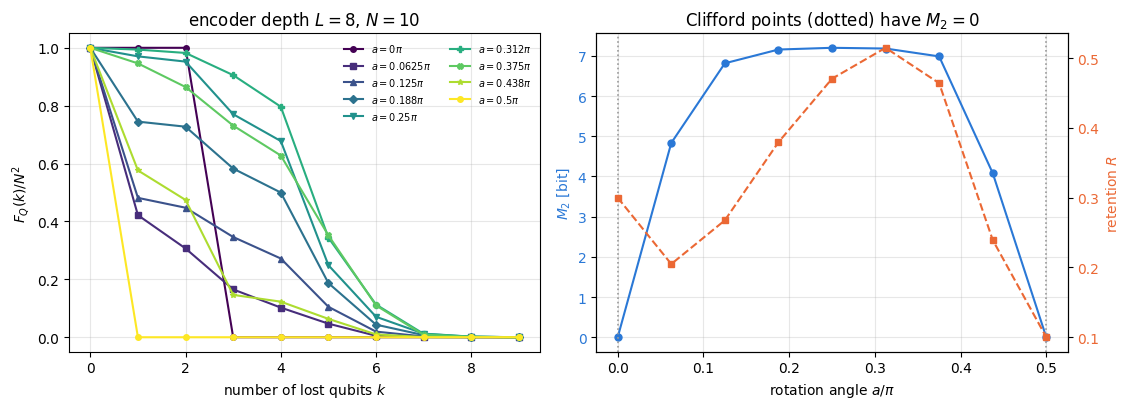

In [17]:
# ==============================================================================
# FIGURE 3: magic of the encoder, and the shape of the loss curve
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2))
for j, a in enumerate(ANGLES):
    axes[0].plot(np.arange(N_ENC), magic_tab[a] / N_ENC ** 2, "-", marker=MARKERS[j % 8],
                 color=plt.cm.viridis(j / (len(ANGLES) - 1)), ms=4, label=f"$a={a / np.pi:.3g}\\pi$")
axes[0].set_xlabel("number of lost qubits $k$"); axes[0].set_ylabel(r"$F_Q(k)/N^2$")
axes[0].set_title(f"encoder depth $L={L_MAGIC}$, $N={N_ENC}$"); axes[0].legend(fontsize=7, ncol=2)

aa = ANGLES / np.pi
m2v = np.array([magic_m2[a] for a in ANGLES])
Rv2 = np.array([float(np.mean(magic_tab[a] / magic_tab[a][0])) for a in ANGLES])
ax2 = axes[1]
ax2.plot(aa, m2v, "o-", color=PALETTE[0], ms=5, label=r"magic $M_2$ [bit]")
ax2.set_xlabel(r"rotation angle $a/\pi$"); ax2.set_ylabel(r"$M_2$ [bit]", color=PALETTE[0])
ax2.tick_params(axis="y", labelcolor=PALETTE[0])
ax3 = ax2.twinx(); ax3.grid(False)
ax3.plot(aa, Rv2, "s--", color=PALETTE[1], ms=5, label="retention $R$")
ax3.set_ylabel("retention $R$", color=PALETTE[1]); ax3.tick_params(axis="y", labelcolor=PALETTE[1])
for a_c in (0.0, 0.5):
    ax2.axvline(a_c, color="0.6", ls=":", lw=1.2)
ax2.set_title("Clifford points (dotted) have $M_2=0$")
fig.tight_layout(); plt.show()

Three facts from the table, in order of importance.

1. **Magic changes the *shape* of the loss curve, from a step to a slope.** At the two Clifford angles $a=0$ and
   $a=\pi/2$ the curve is the staircase of Section 9 — $1,1,1,0,0,\dots$ and $1,0,0,\dots$ respectively. At every
   non-Clifford angle the curve takes intermediate values; no non-Clifford row has the pattern $1,\dots,1,0,\dots,0$.
   The staircase is the three-case rule of Section 9.1, which holds for every stabilizer code; a non-Clifford encoder
   is not a stabilizer code and the rule does not apply.
2. **Magic does not buy a larger protected block.** The best Clifford point ($a=0$, $M_2=0$) keeps the full $N^2$ up
   to $k=2$ lost qubits. The most magical encoder ($a=\pi/4$, $M_2=7.20$ of a maximal $9.00$) retains $97\%$ and
   $95\%$ at $k=1,2$ — slightly less — and then $77\%$, $68\%$ at $k=3,4$ where the Clifford encoder has already
   fallen to zero. Which is "better" depends on whether an experiment can tolerate a $30\%$ loss of $F_Q$; there is
   no universal winner.
3. **Retention is not a monotone function of $M_2$.** At $a=\pi/16$ the state already carries $M_2=4.83$ bit of
   magic, more than half the upper bound, and yet its retention $R=0.20$ is *below* the zero-magic Clifford value
   $R=0.30$. The half-chain entropy does not do better at that point (it rises from $1.00$ to $2.19$ while $R$ falls),
   and over the nine angles $R$ correlates about equally with both columns (Pearson $0.81$ with $S(N/2)$, $0.71$ with
   $M_2$; rank correlation $0.84$ and $0.82$). Nine points of one family do not separate the two.

> **Common pitfall.** A one-parameter family in which two quantities rise together is not evidence that one causes
> the other. Here the knob changes magic, entanglement and operator spreading simultaneously. The Clifford endpoints
> show that zero magic is compatible with both good ($a=0$) and no ($a=\pi/2$) protection, and Section 9 found the
> largest last-block protection, $k^*=5$, with a pure Clifford encoder.

## 11. What the protection costs: sensitivity to a local generator

Section 9 used the encoder to protect a phase that had already been imprinted. Suppose instead we want to use the
encoded state *as a probe*: prepare $V\vert\mathrm{GHZ}\rangle$, and let a physical field imprint the phase through a
**local, collective** generator $J_z$ — a magnetic field acting on every atom the same way, which is what a
magnetometer actually has. Now the generator is fixed by physics, not by our bookkeeping.

There is a general expectation from quantum error correction: a code that protects against local errors must be
*insensitive* to local operators, because a code whose codewords could be distinguished by a local measurement would
not protect against a local error in the first place. A related, proven statement in quantum metrology concerns
Markovian noise during the sensing: a signal Hamiltonian lying inside the span of the noise operators cannot be
measured better than at the standard quantum limit (Demkowicz-Dobrzański, Czajkowski and Sekatski 2017; Zhou, Zhang, Preskill and Jiang 2018, whose "Hamiltonian
not in Lindblad span" criterion is exactly the condition for the obstruction *not* to apply).

Our setting (a static code, erasures after the sensing) is not the setting of those theorems, and we do not prove
a general statement here. We measure the trade-off for our encoders. In the table, $k^*$ is the largest $k$ for which
the survivors of a loss of the last $k$ qubits keep more than half of $F_Q(0)$; for the Clifford encoder this is the
$k^*$ of Section 9.

In [18]:
# ==============================================================================
# STEP 10: protection depth versus sensitivity to the fixed collective generator J_z
# ==============================================================================
print(f"N = {N_ENC}.  Left: the encoder used to PROTECT an imprinted phase (Section 9).")
print(f"            Right: the same encoded state used as a PROBE for a fixed collective generator.\n")
print(f"{'encoder':>16s} {'L':>3s} | {'k* (erasure)':>13s} | {'F_Q[V psi, J_z]':>16s} "
      f"{'max_n F_Q[V psi, n.J]':>22s} {'M_2':>8s}")
tradeoff = {}
for lname, layer in (("Clifford", clifford_layer), ("Ry(pi/4)+CNOT", partial(magic_layer, angle=np.pi / 4))):
    rows = []
    for L in range(L_MAX_C + 1):
        psi, phi = encode_pipeline(N_ENC, layer, L)
        c = np.array([float(block_qfi(psi, phi, range(N_ENC - k))) for k in range(N_ENC)])
        kstar = max([k for k in range(N_ENC) if c[k] > 0.5 * c[0]], default=0)    # last-k block, F_Q > F_Q(0)/2
        fz = float(qfi_pure(psi, Z))                          # F_Q for G = J_z, the FIXED physical generator
        fmax = float(optimal_direction(psi)[0])               # best collective direction
        rows.append((L, kstar, fz, fmax, sre(psi)))
        print(f"{lname:>16s} {L:3d} | {kstar:13d} | {fz:16.4f} {fmax:22.4f} {rows[-1][4]:8.4f}")
    tradeoff[lname] = np.array(rows)

# --- CHECK of the explanation below: F_Q[J_z] = N + sum_{q != q'} <Z_q Z_q'> - (sum_q <Z_q>)^2 ---------------
# For a stabilizer state every Pauli expectation is 0 or +-1, so F_Q[J_z] = N EXACTLY iff all one- and two-point
# Z correlators vanish.  We check that this is what happens for every Clifford depth L >= 1.
z_max = 0.0
for L in range(1, L_MAX_C + 1):
    psi, _ = encode_pipeline(N_ENC, clifford_layer, L)
    zpsi = [apply_gate(psi, Z, [q]) for q in range(N_ENC)]
    z1 = max(abs(float(jnp.real(jnp.vdot(psi, zq)))) for zq in zpsi)
    z2 = max(abs(float(jnp.real(jnp.vdot(zpsi[q], zpsi[r])))) for q in range(N_ENC) for r in range(q + 1, N_ENC))
    z_max = max(z_max, z1, z2)
print(f"\nClifford L = 1..{L_MAX_C}: largest |<Z_q>| and |<Z_q Z_q'>| = {z_max:.1e}   (GHZ, L = 0: all <Z_q Z_q'> = 1)")
assert z_max < 1e4 * TOL

N = 10.  Left: the encoder used to PROTECT an imprinted phase (Section 9).
            Right: the same encoded state used as a PROBE for a fixed collective generator.

         encoder   L |  k* (erasure) |  F_Q[V psi, J_z]  max_n F_Q[V psi, n.J]      M_2
        Clifford   0 |             0 |         100.0000               100.0000   0.0000


        Clifford   1 |             2 |          10.0000                13.5311   0.0000
        Clifford   2 |             4 |          10.0000                10.0000   0.0000


        Clifford   3 |             5 |          10.0000                11.4142   0.0000


        Clifford   4 |             4 |          10.0000                11.0000   0.0000


        Clifford   5 |             3 |          10.0000                10.0000   0.0000


...

   Ry(pi/4)+CNOT   2 |             0 |           8.3257                30.9960   5.5364
   Ry(pi/4)+CNOT   3 |             0 |          11.0194                14.8968   5.4967


   Ry(pi/4)+CNOT   4 |             0 |           9.0115                12.5788   5.2728


   Ry(pi/4)+CNOT   5 |             2 |           9.4681                11.6567   6.3441


   Ry(pi/4)+CNOT   6 |             2 |           9.5881                 9.8197   7.0251



Clifford L = 1..6: largest |<Z_q>| and |<Z_q Z_q'>| = 4.9e-17   (GHZ, L = 0: all <Z_q Z_q'> = 1)


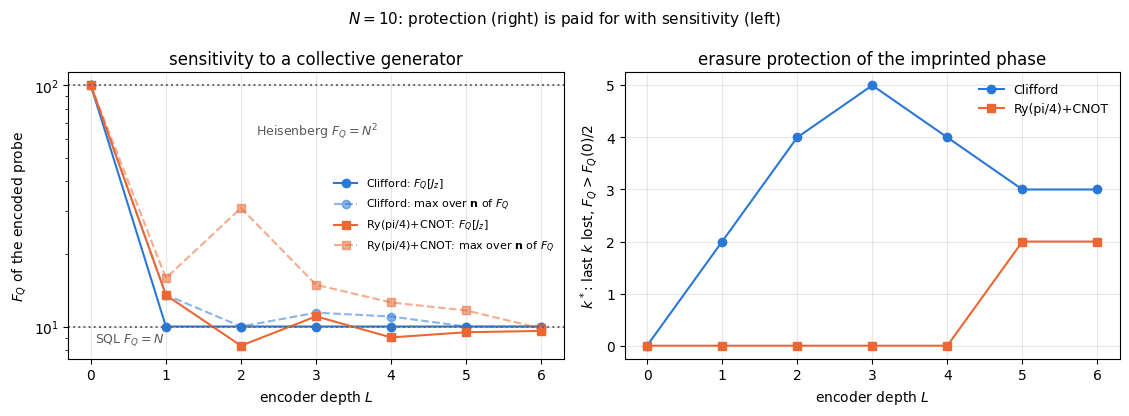

In [19]:
# ==============================================================================
# FIGURE 4: the protection / sensitivity trade-off
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2))
for j, (lname, rows) in enumerate(tradeoff.items()):
    axes[0].plot(rows[:, 0], rows[:, 2], MARKERS[j] + "-", color=PALETTE[j], ms=6, label=f"{lname}: $F_Q[J_z]$")
    axes[0].plot(rows[:, 0], rows[:, 3], MARKERS[j] + "--", color=PALETTE[j], ms=6, alpha=0.55,
                 label=f"{lname}: max over $\\mathbf{{n}}$ of $F_Q$")
    axes[1].plot(rows[:, 0], rows[:, 1], MARKERS[j] + "-", color=PALETTE[j], ms=6, label=lname)
axes[0].axhline(N_ENC, color="0.4", ls=":", lw=1.4)
axes[0].text(0.05, N_ENC * 0.86, "SQL $F_Q=N$", fontsize=9, color="0.35")
axes[0].axhline(N_ENC ** 2, color="0.4", ls=":", lw=1.4)
axes[0].text(2.2, N_ENC ** 2 * 0.62, "Heisenberg $F_Q=N^2$", fontsize=9, color="0.35")
axes[0].set_yscale("log"); axes[0].set_xlabel("encoder depth $L$")
axes[0].set_ylabel(r"$F_Q$ of the encoded probe")
axes[0].set_title("sensitivity to a collective generator"); axes[0].legend(fontsize=8, loc="center right")
axes[1].set_xlabel("encoder depth $L$")
axes[1].set_ylabel(r"$k^*$: last $k$ lost, $F_Q>F_Q(0)/2$")
axes[1].set_title("erasure protection of the imprinted phase"); axes[1].legend(fontsize=9)
fig.suptitle(f"$N={N_ENC}$: protection (right) is paid for with sensitivity (left)", fontsize=11)
fig.tight_layout(); plt.show()

The trade-off appears at the **first layer**. With no encoder the probe is a GHZ state: $F_Q=N^2=100$ for $G=J_z$ and
no erasure protection at all. One Clifford layer protects the last two qubits and takes the collective QFI down to
$F_Q\left[V\psi,J_z\right]=10=N$ — the standard quantum limit, exactly. Every deeper Clifford encoder in the table
stays at exactly $10$, and optimising the direction over the whole sphere recovers at most $F_Q=13.53$, i.e.
$1.35\,N$. The magic encoder behaves the same way for the physical generator: $F_Q[J_z]$ ranges over $8.33$–$13.50$
for $L=1,\dots,6$, a factor of seven or more below $N^2$. Its optimal *direction* does somewhat better at one depth
($F_Q=31.0$ at $L=2$, i.e. $3.1\,N$) — these are small systems, and a shallow non-Clifford circuit has not yet removed
all collective correlations — but even that is a factor of three below the Heisenberg value it started from.

The value "exactly $N$" has a short explanation. Expanding $4\,\mathrm{Var}(J_z)$,

$$F_Q[J_z]=N+\sum_{q\neq q'}\langle Z_qZ_{q'}\rangle-\Big(\sum_q\langle Z_q\rangle\Big)^2 ,$$

and for a stabilizer state every Pauli expectation value is $0$ or $\pm1$. The GHZ state has all $N(N-1)$ two-point
terms equal to $1$ (hence $N^2$); after one Clifford layer none of the strings $Z_q$, $Z_qZ_{q'}$ is $\pm$ an element of
the stabilizer group any more, every correlator vanishes (checked above for every $L\ge1$), and $F_Q=N$ exactly. The
Heisenberg value of the GHZ state sits entirely in its two-body $ZZ$ correlations; the encoder moves the corresponding
stabilizers to longer Pauli strings, which a sum of single-qubit generators cannot see.

Between $L=0$ and $L=1$ the two panels of the figure move in opposite directions; beyond $L=1$ the sensitivity to
$J_z$ stays at the standard quantum limit whatever the protection does. **The encoded state protects a phase it
already holds, and is a poor probe for a new one**, because the operator that generated the phase in the code space,
$VJ_zV^\dagger$, is a complicated many-body operator, while the field in the laboratory couples through the simple
$J_z$.

> **Physics insight.** Quantum-error-corrected metrology has to work around this obstruction, and the
> literature's answer is to interleave sensing and correction instead of encoding after the fact: correct errors fast, on a time scale short
> compared with the signal accumulation, using a code chosen so that the signal Hamiltonian is **not** inside the span
> of the noise (Kessler, Lovchinsky, Sushkov and Lukin 2014; Dür, Skotiniotis, Fröwis and Kraus 2014; Zhou, Zhang,
> Preskill and Jiang 2018). Our static experiment sits at the unfavourable end of that story on purpose: it shows
> what the constraint looks like when nothing is done about it.

## 12. The entanglement spectrum of the encoders, and Marchenko–Pastur

One last diagnostic, and the one that separates the Clifford and magic encoders most sharply. The **entanglement
spectrum** across the half cut is the set of eigenvalues $\lambda_i$ of $\rho_A$ for $\vert A\vert=N/2$. It is
convenient to rescale them by the dimension, $x_i=\lambda_i d_A$ with $d_A=2^{N/2}$, so that
$\langle x\rangle=1$ always.

* A **stabilizer state** has a flat spectrum: $\lambda_i=2^{-S}$ on a subspace of dimension $2^S$ and zero elsewhere.
  (Writing $\vert\psi\rangle\langle\psi\vert=2^{-N}\sum_{P\in\mathcal S}P$ over the $2^N$ elements of the stabilizer
  group, the partial trace kills every element not supported on $A$, so
  $\rho_A=2^{-\vert A\vert}\sum_{P\in\mathcal S_A}P$ with $\mathcal S_A$ the subgroup supported on $A$; and
  $\vert\mathcal S_A\vert^{-1}\sum_{P\in\mathcal S_A}P$ is a projector.) Rescaled, the spectrum is a single spike at
  $x=d_A2^{-S}$ plus a pile of exact zeros.
* A **Haar-random state** at $d_A=d_B=d$ has, in the large-$d$ limit, the **Marchenko–Pastur** density with aspect
  ratio $\gamma=d_A/d_B=1$,

$$p(x)=\frac{1}{2\pi}\sqrt{\frac{4-x}{x}},\qquad 0\le x\le4, \tag{19}$$

  with mean $1$ and variance $1$. (This is the $\gamma=1$ case of the classical Marchenko–Pastur law for the
  eigenvalues of a Wishart matrix $\Psi\Psi^\dagger$ with independent Gaussian entries — which is exactly what
  $\rho_A$ is for a Haar-random pure state, up to normalisation.)

So the question "how random does the encoder make the state" has a quantitative answer, and we can ask whether magic
is what moves a spectrum from the first shape to the second.

In [20]:
# ==============================================================================
# STEP 11: half-cut entanglement spectra, and the Marchenko-Pastur reference
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_SP = 14                        # 2^14 amplitudes; half cut -> 128 x 128, i.e. 128 Schmidt values per state
L_SP = 12                        # encoder depth
SP_ANGLES = [0.0, 0.125 * np.pi, 0.25 * np.pi]
N_SP_REAL = 8                    # realisations for the random references
# -----------------------------------------------------------------------------


def half_cut_spectrum(psi):
    """Rescaled entanglement spectrum x_i = lambda_i * d_A across the middle cut (mean(x) = 1 by construction)."""
    K = psi.ndim // 2
    return np.array(schmidt_values(psi, range(K))) ** 2 * 2 ** K


def mp_density(x, gamma=1.0):
    """Marchenko-Pastur density, Eq. (19) generalised to aspect ratio gamma = d_A/d_B <= 1."""
    xm, xp = (1 - np.sqrt(gamma)) ** 2, (1 + np.sqrt(gamma)) ** 2
    out = np.zeros_like(x)
    m = (x > xm) & (x < xp)
    out[m] = np.sqrt((xp - x[m]) * (x[m] - xm)) / (2 * np.pi * gamma * x[m])
    return out


def spectrum_stats(sample_list):
    """(pooled rescaled spectrum, mean rank, mean entanglement entropy in bits) over a list of states."""
    xs = [half_cut_spectrum(p) for p in sample_list]
    d = 2 ** (sample_list[0].ndim // 2)
    rank = np.mean([np.sum(x > 1e-12) for x in xs])
    ent = np.mean([-np.sum((x[x > 1e-16] / d) * np.log2(x[x > 1e-16] / d)) for x in xs])
    return np.concatenate(xs), rank, ent


samples = {}
for a in SP_ANGLES:
    samples[f"encoder $a={a / np.pi:.3g}\\pi$"] = [encode_pipeline(N_SP, partial(magic_layer, angle=a), L_SP)[0]]
samples["Haar random"] = [haar_state(jax.random.PRNGKey(r), N_SP) for r in range(N_SP_REAL)]
samples[f"brick wall, depth {N_SP}"] = [brickwall(jax.random.PRNGKey(r), product_state("0" * N_SP), N_SP)
                                        for r in range(N_SP_REAL // 2)]

print(f"N = {N_SP}, half cut ({N_SP // 2}|{N_SP // 2}), rescaled spectrum x = lambda * 2^{N_SP // 2}"
      f"  (Page value of S: {(np.log(2 ** (N_SP // 2)) - 0.5) / np.log(2):.3f} bit)\n")
print(f"{'state':>26s} {'#states':>8s} {'rank':>7s} {'mean x':>8s} {'std x':>8s} {'max x':>8s} {'S(N/2) [bit]':>13s}")
spectra = {}
for name, states in samples.items():
    x, rank, ent = spectrum_stats(states)
    spectra[name] = x
    print(f"{name:>26s} {len(states):8d} {rank:7.1f} {x.mean():8.4f} {x.std():8.4f} {x.max():8.3f} {ent:13.4f}")
print(f"\nMarchenko-Pastur (gamma = 1): support [0, 4], mean 1, standard deviation 1")

N = 14, half cut (7|7), rescaled spectrum x = lambda * 2^7  (Page value of S: 6.279 bit)

                     state  #states    rank   mean x    std x    max x  S(N/2) [bit]
          encoder $a=0\pi$        1     2.0   1.0000   7.9373   64.000        1.0000
      encoder $a=0.125\pi$        1   128.0   1.0000   1.9966   17.517        5.5604
       encoder $a=0.25\pi$        1   128.0   1.0000   1.0544    4.167        6.2199
               Haar random        8   128.0   1.0000   1.0015    3.949        6.2785
      brick wall, depth 14        4   128.0   1.0000   2.4564   18.210        4.8409

Marchenko-Pastur (gamma = 1): support [0, 4], mean 1, standard deviation 1


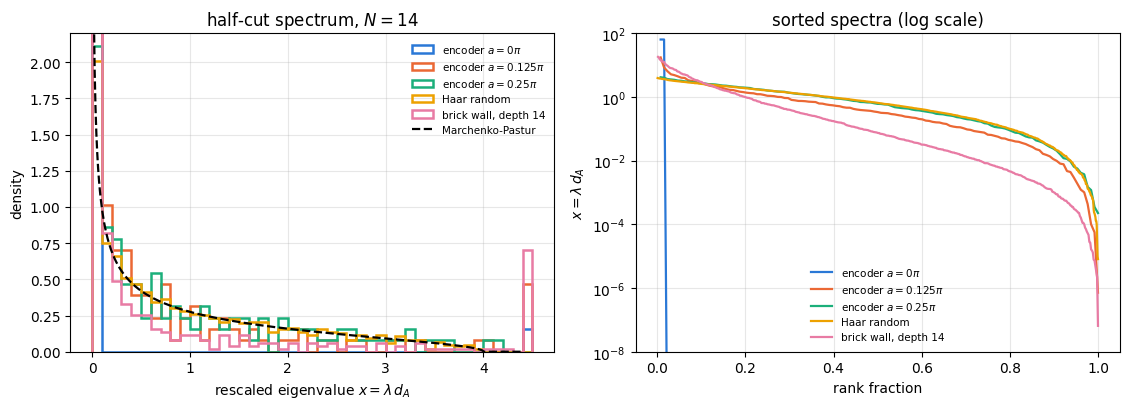

In [21]:
# ==============================================================================
# FIGURE 5: entanglement spectra against Marchenko-Pastur
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2))
xg = np.linspace(1e-4, 4.4, 500)
bins = np.linspace(0, 4.5, 46)
for j, (name, x) in enumerate(spectra.items()):
    axes[0].hist(np.clip(x, 0, 4.4), bins=bins, density=True, histtype="step", lw=1.8,
                 color=PALETTE[j], label=name)
axes[0].plot(xg, mp_density(xg), "k--", lw=1.6, label="Marchenko-Pastur")
axes[0].set_xlabel(r"rescaled eigenvalue $x=\lambda\,d_A$"); axes[0].set_ylabel("density")
axes[0].set_ylim(0, 2.2); axes[0].set_title(f"half-cut spectrum, $N={N_SP}$")
axes[0].legend(fontsize=7.5)

for j, (name, x) in enumerate(spectra.items()):
    xs = np.sort(x)[::-1]
    axes[1].semilogy(np.arange(1, len(xs) + 1) / len(xs), np.clip(xs, 1e-12, None), "-",
                     color=PALETTE[j], lw=1.6, label=name)
axes[1].set_xlabel("rank fraction"); axes[1].set_ylabel(r"$x=\lambda\,d_A$")
axes[1].set_ylim(1e-8, 1e2); axes[1].set_title("sorted spectra (log scale)")
axes[1].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

(Everything above $x=4.4$ is clipped into the last histogram bin, which is why the Clifford, the $a=\pi/8$ and the
brick-wall curves have a spike there.)

The Clifford encoder ($a=0$) produces exactly what a stabilizer state must: two non-zero eigenvalues out of $128$,
both equal, sitting at $x=64$ — in the right panel a flat plateau that drops to zero after a rank fraction of
$1/64$, i.e. one bit of entanglement entropy against the Page value of $6.28$. There is nothing in between: the
non-zero part of a stabilizer state's entanglement spectrum is a single degenerate level.

Turning on the magic fills it. At $a=\pi/8$ the rank is already full ($128$ out of $128$) and the entropy has climbed
to $5.56$ bit, but the distribution is much broader than Marchenko–Pastur: $\mathrm{std}(x)=2.00$ against $1$, and a
maximum at $x=17.5$ against the Marchenko–Pastur edge at $4$. At $a=\pi/4$ the spectrum is close to the random-matrix
prediction — $\mathrm{std}(x)=1.05$, maximum $4.17$, entropy $6.22$ bit — and the histogram tracks the dashed curve
over its whole support. The Haar reference gives $\mathrm{std}(x)=1.0015$, maximum $3.95$ and entropy $6.2785$ bit,
equal to the Page value $6.279$ to within $10^{-3}$, while a brick wall of Haar *two-qubit* gates with $N=14$ layers
(one layer = the even or the odd bonds) is still far from converged ($\mathrm{std}=2.46$, entropy $4.84$ bit): the
entanglement of a nearest-neighbour circuit grows at a finite rate per layer, and $14$ layers are not enough at
$N=14$.

So a Clifford circuit, however deep, cannot produce a random-matrix entanglement spectrum: by the projector argument
above its spectra stay flat, and the non-Clifford rotations are what fill them in. This is the spectral counterpart
of the staircase of Sections 9–10, whose derivation (Section 9.1) used the same stabilizer structure. What magic is
*not* is a measure of how much metrological information survives.

## 13. Cost

| quantity | algorithm | time | memory |
|---|---|---|---|
| tangent vector $G\vert\psi\rangle$ | $N$ einsums | $O(N2^N)$ | $O(2^N)$ |
| $F_Q$ of a block, compressed | thin QR plus a small `eigh` | $O\!\left(8^{\min(K,N-K)}\right)$ | $O(2^N)$ |
| $F_Q$ of a block, naive | dense `eigh` of $\rho_A$ | $O(8^{K})$ | $O(4^{K})$ |
| magic $M_2$ | Walsh–Hadamard over all $X$-patterns | $O(N4^N)$ | $O(\texttt{batch}\cdot2^N)$ |
| encoder layer | $N$ one-qubit and $N-1$ two-qubit einsums | $O(N2^N)$ | $O(2^N)$ |
| half-cut spectrum | one SVD of a $2^{N/2}\times2^{N/2}$ matrix | $O(2^{3N/2})$ | $O(2^N)$ |

The magic calculation is the wall: $N4^N$ grows so fast that $N=12$ costs $4^4\cdot12/8=384$ times $N=8$. The subsystem QFI is
cheap *because* of the compression, and the table below shows by how much.

In [22]:
# ==============================================================================
# STEP 12: measured cost
# ==============================================================================
psi_t = haar_state(jax.random.PRNGKey(4), 12)
phi_t = collective_tangent(psi_t, (0, 0, 1))
print("Block QFI at N = 12, keeping K qubits: Schmidt compression on and off\n")
print(f"{'K':>3s} {'d_A':>6s} {'d_B':>6s} | {'compressed [ms]':>16s} {'naive [ms]':>12s} {'speed-up':>9s}")
for K in (2, 4, 6, 8, 10, 11):
    fc = jax.jit(partial(block_qfi, keep=tuple(range(K)), compress=True))
    _, _, tc = timed(fc, psi_t, phi_t, budget=0.15)
    if K <= 9:
        fn = jax.jit(partial(block_qfi, keep=tuple(range(K)), compress=False))
        _, _, tn = timed(fn, psi_t, phi_t, budget=0.15)
        ratio = f"{tn / tc:9.1f}"
    else:
        tn, ratio = float("nan"), f"{'--':>9s}"
    print(f"{K:3d} {2 ** K:6d} {2 ** (12 - K):6d} | {tc * 1e3:16.3f} {tn * 1e3:12.3f} {ratio}")

print("\nMagic M_2 (Walsh-Hadamard, O(N 4^N)); the first call of each N compiles, so we time the second\n")
print(f"{'N':>3s} {'4^N':>12s} | {'compile+run [s]':>16s} {'run [s]':>10s}")
for N in (6, 8, 10, 12):
    p = haar_state(jax.random.PRNGKey(0), N)
    t0 = time.time(); _ = sre(p); t1 = time.time(); _ = sre(p); t2 = time.time()
    print(f"{N:3d} {4 ** N:12d} | {t1 - t0:16.3f} {t2 - t1:10.3f}")

Block QFI at N = 12, keeping K qubits: Schmidt compression on and off

  K    d_A    d_B |  compressed [ms]   naive [ms]  speed-up


  2      4   1024 |            0.050        0.052       1.0


  4     16    256 |            0.133        0.139       1.0


  6     64     64 |            1.057        1.121       1.1


  8    256     16 |            0.590       18.137      30.8
 10   1024      4 |            0.146          nan        --


 11   2048      2 |            0.105          nan        --

Magic M_2 (Walsh-Hadamard, O(N 4^N)); the first call of each N compiles, so we time the second

  N          4^N |  compile+run [s]    run [s]


  6         4096 |            0.189      0.001


  8        65536 |            0.243      0.004
 10      1048576 |            0.046      0.045


 12     16777216 |            1.383      1.070


Compression matters most where the physics is: the interesting regime is "one or two particles lost", i.e. $K$ close
to $N$, which is precisely where the naive $O(8^K)$ eigendecomposition explodes. The measured compressed time peaks
at the balanced cut $K=6$ and falls on both sides, as $O\!\left(8^{\min(K,N-K)}\right)$ predicts (it is not exactly
symmetric, because for $K>N/2$ the QR of a $2^K\times2^{N-K+1}$ matrix adds its own cost), while the naive route
keeps growing and is twenty to thirty times slower at $K=8$ (the exact factor varies between runs on a shared machine). For $K\ge10$
the naive version is not run at all: it would diagonalise a $1024\times1024$ matrix that we know in advance has rank
at most $4$.

The magic timings show the $4^N$ wall arriving. Once compilation is separated from execution, the run time climbs
from a few milliseconds at $N=6$ — where the measurement is Python dispatch, not arithmetic — to of order a second
at $N=12$ (the $N=10$ program was already compiled for the zoo, hence its small first-call time), the last step alone worth a factor of twenty to thirty, in line with the asymptotic $16\times$ per two
qubits times the extra $N/(N-2)$. Each further pair of qubits costs another factor of that size, which is why the
magic experiments stop at $N=10$ while the entanglement spectra run comfortably at $N=14$ and the subsystem QFI at
$N=12$.

## 14. Key takeaways

* **Loss is a partial trace, and the QFI of the survivors is the SLD formula on the reduced state.** For a generator
  that is a sum of single-qubit terms the problem is purely local: $\partial_\theta\rho_A=-i[G_A,\rho_A]$, so the
  survivors behave as if only their own share of the generator existed (Eq. 3, verified against `qfi_mixed` to
  better than $10^{-13}$). For a general generator, carry a **tangent vector** $\vert\phi\rangle=G\vert\psi\rangle$ alongside the
  state and use $\partial_\theta\rho_A=-i(T-T^\dagger)$, $T=\Phi\Psi^\dagger$ (Eq. 4).
* **Four loss laws, derived and confirmed exactly.** Product: $F_Q=K$. GHZ with its own generator: $F_Q=0$ for every
  $k\ge1$; re-optimised to $J_x$: $F_Q=K$ exactly, the standard quantum limit of the survivors. Dicke:
  $F_Q=\sum_m(m+1)(K-m)(w_m-w_{m+1})^2/(w_m+w_{m+1})$ with hypergeometric Schmidt weights. W (its $M=1$ member):
  $F_Q=K(1-2K/N)^2+2K(K-1)/N$, which gives $3N-2$ at $K=N$.
* **Measure the loss budget, not the retained fraction.** At $N=10$ the number of particles that may be lost while the
  survivors still beat their own standard quantum limit is $5$ for the optimally squeezed probe, $4$ for the W state,
  $3$ for the over-squeezed and half-filled Dicke probes, $2$ for the Haar-random state and $0$ for GHZ, the cat and
  the product state. Relative retention ranks the useless product state first.
* **The spectrum of the survivors does not decide.** Three probes leave exactly the same rank-$2$ spectrum
  $(0.5,0.5)$ after one loss and give $F_Q=0$ (GHZ), $0$ (cat) and $24.0$ (Dicke $N/2$). What decides
  is whether $G_A$ has matrix elements out of the support of $\rho_A$ — Eq. (13) — i.e. whether the generator can
  still move the survivors.
* **Magic does not predict robustness.** Over the probe zoo the two zero-magic stabilizer states sit at opposite ends
  of the ranking, and eight hand-picked probes support no correlation. What magic *does* change is the **shape** of
  the loss curve: for a stabilizer code the survivors can measure all, none or exactly one logical operator, so
  $F_Q$ is $0$ or $N^2$ (Section 9.1) and the loss curve is a staircase; the non-Clifford encoders give intermediate
  values.
* **A phase can be protected.** Imprinting on GHZ and then encoding with $L$ Clifford layers makes the probe an
  erasure code: at $N=10$ the full $F_Q=N^2$ survives the loss of the last $k^*=0,2,4,5,4,3,3$ qubits for
  $L=0,\dots,6$, with nothing in between. Over *all* erasure patterns the guaranteed protection is only
  $0,0,1,1,2,2,1$. Both are non-monotone in depth — a longer circuit is not automatically a better code — and
  $F_Q=N^2$ at $\theta=0$ is not the same as a correctable erasure (the $\bar X$-only and $\bar Y$-only cases).
* **Protection is paid for in sensitivity.** The same Clifford encoders take the collective quantum Fisher
  information of the encoded state from $F_Q[J_z]=N^2=100$ down to exactly $N=10$ at $L=1$ and keep it there (all
  one- and two-point $Z$ correlators vanish), with at most $1.35\,N$ recoverable by optimising the generator direction. What the code protects (a phase already written
  into the logical qubit) is not what a magnetometer needs (sensitivity to a local field).
* **Magic is what a flat spectrum lacks.** The half-cut entanglement spectrum of a Clifford-encoded state is a single
  degenerate level; at maximal magic the same circuit produces a spectrum that follows the Marchenko–Pastur law
  closely, and a brick wall of Haar two-qubit gates at depth $N$ does not. Randomness in the entanglement spectrum
  requires magic; metrological usefulness does not.

## 15. Exercises

1. ★ **Read the loss laws.** Using Eq. (12), compute $F_Q$ of a W state of $N=100$ atoms after losing $1$, $10$ and
   $50$ atoms, and find the largest $k$ for which the survivors still beat their own standard quantum limit $K$.
   Compare with the exact GHZ answer of Eq. (7) and state which probe has the larger $F_Q$ after $1\%$ and after
   $10\%$ of the atoms are lost. (Check: $F_Q=289.12$, $217.8$, $49$; the last $k$ is $49$.)
2. ★ **The other Dicke states.** Evaluate `dicke_loss_qfi(12, M, K)` for $M=1,2,3,6$ and all $K$, and plot the loss
   budget $k_{\rm SQL}$ against $M$. Is half filling optimal for robustness as it is for $F_Q$ itself?
   (Check: $F_Q(0)=34,52,66,84$ and $k_{\rm SQL}=5,4,4,4$.)
3. ★★ **Which qubits matter (extend the code).** `block_qfi` accepts an arbitrary set of kept qubits. For the
   Clifford-encoded probe at $L=2$, $N=10$, compute $F_Q$ for every *contiguous* erased block of size $k=3$, and list
   the fatal ones. Use `logicals_on` of Section 9.2 to name, for each fatal block, the logical operator it supports,
   and relate the answer to the light cone of the encoder (each layer moves information by at most two sites).
4. ★★ **A threshold metric (physics).** Define the loss budget with a threshold:
   $k_\epsilon=\max\{k:F_Q(k)>\epsilon N^2\}$, and set $k_\epsilon=-1$ when even the intact probe has
   $F_Q(0)\le\epsilon N^2$. Recompute the zoo ranking for $\epsilon=0.5,0.1,0.01$ and describe how the ranking changes.
   Which probes are robust to a redefinition of "useful"?
5. ★★ **Magic of the codewords (extend the code).** Section 10 measured the magic of the encoded *probe*. Measure
   instead the magic of the two codewords $\vert\bar0\rangle$ and $\vert\bar1\rangle$ separately along the
   `magic_layer` family, and check whether the loss curve is a staircase exactly when both codewords are stabilizer
   states.
6. ★★ **Depth is not distance (physics).** For the Clifford encoder and $L=1,\dots,8$, find the smallest erasure
   pattern that is fatal at $\theta=0$ (scan $k=1,2,3$ with `logicals_on`), print which logical operator
   ($\bar X$, $\bar Y$ or $\bar Z$) it supports, and plot the guaranteed protection of Section 9.2 against $L$. Then
   verify the $\bar X$-only row of the table of Section 9.1 directly: for one such pattern, plot $F_Q$ of the survivors
   against $\theta\in[0,0.1]$ with `encode_pipeline_theta` and confirm that it is $0$ at $\theta=0$ and $N^2$ at every
   $\theta\neq0$ (the classical Fisher information $\sin^2\varphi/(1-\cos^2\varphi)$ of Section 9.1).
7. ★★★ **Optimal robust probe (extend the code).** Parametrise a state in the symmetric (Dicke) subspace of $N=10$ by
   $N+1$ real amplitudes, $\vert\psi\rangle\propto\sum_Mc_M\vert D_N^M\rangle$, and maximise $F_Q$ of the survivors after
   the loss of $k=2$ qubits, for the generator $J_z$. The reduced state has many exactly zero eigenvalues, where the
   derivative of `eigh` is undefined: either use a derivative-free optimiser (e.g. `scipy.optimize.minimize` with
   `method="Powell"`, several random starts) or regularise $\rho_A\to\rho_A+\epsilon\mathbb 1$ with $\epsilon\sim10^{-8}$
   before differentiating with `jax.grad`. Compare the optimum with the squeezed probe of Section 5 at $k=2$.
   (Check: the optimum is $F_Q\approx16.0$, against $15.96$ for the optimally squeezed probe and $13.71$ for the
   Dicke state; its intact value is $F_Q(0)\approx40$.)
8. ★★★ **Interleaved imprinting (extend the code).** Replace the single imprint-then-encode step of Eq. (15) by $R$
   rounds of "imprint $\theta/R$ with $J_z$, then apply one Clifford layer", for $R=1,\dots,6$. The tangent vector at
   $\theta=0$ is $\frac1R\sum_{r=1}^{R}V^{R-r+1}J_zV^{r-1}\vert\mathrm{GHZ}\rangle$ ($V$ = one layer). Measure the full
   $F_Q$ and $F_Q$ of the survivors after the loss of the last $k$ qubits, and compare with the two extremes of the
   same total depth: all imprinting first (Section 9, $L=R$) and all encoding first (Section 11, $F_Q[V^R\psi,J_z]$).
   Does interleaving recover any of the sensitivity lost in Section 11?

## 16. References

* S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*,
  Phys. Rev. Lett. **72**, 3439 (1994) — the quantum Fisher information as the maximum of the classical Fisher
  information over all measurements; the quantum Cramér–Rao bound used throughout.
* L. Pezzè and A. Smerzi, *Entanglement, nonlinear dynamics, and the Heisenberg limit*,
  Phys. Rev. Lett. **102**, 100401 (2009) — $F_Q>N$ as an entanglement witness for collective generators.
* G. Tóth and I. Apellaniz, *Quantum metrology from a quantum information science perspective*,
  J. Phys. A **47**, 424006 (2014) — the review behind the folklore of Sections 4–6; Section 2.2 states that a GHZ
  state "becomes a separable state" already after a single particle is lost, while spin-squeezed states stay optimal.
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states of
  atomic ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the standard review; Dicke states, squeezing, and the
  experimental status of atomic interferometers.
* E. Knill and R. Laflamme, *Theory of quantum error-correcting codes*, Phys. Rev. A **55**, 900 (1997) — the
  error-correction conditions of Eq. (18), and M. Grassl, T. Beth and T. Pellizzari, *Codes for the quantum erasure
  channel*, Phys. Rev. A **56**, 33 (1997) — the same conditions written for erasures, which is the form used here.
* R. Demkowicz-Dobrzański, J. Kołodyński and M. Guţă, *The elusive Heisenberg limit in quantum-enhanced metrology*,
  Nat. Commun. **3**, 1063 (2012) — uncorrelated noise restores standard-quantum-limit scaling.
* R. Demkowicz-Dobrzański, J. Czajkowski and P. Sekatski, *Adaptive quantum metrology under general Markovian noise*,
  Phys. Rev. X **7**, 041009 (2017) — the "Hamiltonian not in Lindblad span" criterion: if the signal generator lies
  in the span of the noise, no adaptive strategy beats the standard quantum limit.
* S. Zhou, M. Zhang, J. Preskill and L. Jiang, *Achieving the Heisenberg limit in quantum metrology using quantum
  error correction*, Nat. Commun. **9**, 78 (2018) — the same criterion as a necessary *and sufficient* condition, and
  the code construction that attains the Heisenberg limit when it holds.
* W. Dür, M. Skotiniotis, F. Fröwis and B. Kraus, *Improved quantum metrology using quantum error correction*,
  Phys. Rev. Lett. **112**, 080801 (2014), and E. M. Kessler, I. Lovchinsky, A. O. Sushkov and M. D. Lukin,
  *Quantum error correction for metrology*, Phys. Rev. Lett. **112**, 150802 (2014) — fast interleaved correction as
  the way around the obstruction of Section 11.
* L. Leone, S. F. E. Oliviero and A. Hamma, *Stabilizer Rényi entropy*, Phys. Rev. Lett. **128**, 050402 (2022) —
  the definition of $M_\alpha$, Eq. (14), and its properties as a magic monotone.
* D. Gottesman, *The Heisenberg representation of quantum computers*, in *Group22: Proceedings of the XXII
  International Colloquium on Group Theoretical Methods in Physics*, eds. S. P. Corney, R. Delbourgo and P. D. Jarvis
  (International Press, Cambridge MA, 1999), pp. 32–43; arXiv:quant-ph/9807006 — the stabilizer formalism and the
  Gottesman–Knill theorem (Clifford circuits acting on stabilizer states are classically simulable), on which
  Sections 9.1 and 12 rely.
* V. A. Marchenko and L. A. Pastur, *Distribution of eigenvalues for some sets of random matrices*,
  Mat. Sb. **72(114)**, 507–536 (1967); English translation Math. USSR-Sb. **1**, 457 (1967) — the law of Eq. (19) itself (a statement about random matrices, not about
  quantum states), and B. Collins and I. Nechita, *Random matrix techniques in quantum information theory*,
  J. Math. Phys. **57**, 015215 (2016) — the review that derives the reduced density matrix of a Haar-random
  bipartite pure state as a normalised Wishart matrix and hence its Marchenko–Pastur spectrum.
* D. N. Page, *Average entropy of a subsystem*, Phys. Rev. Lett. **71**, 1291 (1993) — the entropy of a random
  subsystem, the reference curve behind the Haar-random probe's behaviour.
* M. Kitagawa and M. Ueda, *Squeezed spin states*, Phys. Rev. A **47**, 5138 (1993) — the one-axis-twisting
  Hamiltonian that generates the squeezed and cat probes of Section 5.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/